# <p style="font-family: Cambria; text-align: center; font-size: 44px;">II. DESCRIPTIVE ANALYSIS</p>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Team2_PythonPioneers_Cardiac_Cleaned_Data.csv")
print(df.shape)

(2008, 210)


In [2]:
# ---------- One colour system for every chart in this notebook ----------
INK, MUTED, GRID = "#1f1f1f", "#6b6b6b", "#e6e6e6"
BLUE    = "#2a78d6"   # single-series bars / histograms, and "Readmission"
ORANGE  = "#eb6834"   # second series, and "Death"
FEMALE, MALE = "#2a78d6", "#eb6834"      # gender always uses these two
REF     = "#d03b3b"   # cut-off / normal-limit reference lines only
NEUTRAL = "#b8b6b0"   # "normal" middle group
# Ordered levels (stages, grades, severity): light blue = better -> dark blue = worse
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281", "#0d366b"]
def ramp(n):
    """n evenly spaced steps from the blue ramp (light -> dark)."""
    return [RAMP[i] for i in np.linspace(0, len(RAMP) - 1, n).round().astype(int)]
SEQ = LinearSegmentedColormap.from_list("seq", ["#f4f8fd", "#9ec5f4", "#2a78d6", "#0d366b"])

plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#bdbdbd", "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "font.size": 10, "legend.frameon": False})

def label_bars(ax, fmt="{:.1f}%", horizontal=False):
    for c in ax.containers:
        ax.bar_label(c, labels=[fmt.format(v) for v in c.datavalues], padding=3, fontsize=9, color=INK)

def suptitle(fig, text):
    fig.suptitle(text, fontsize=14, fontweight="bold", x=0.06, ha="left", y=1.02)

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q1. How many patients died or were readmitted within 28 days, 3 months and 6 months?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>outcome_during_hospitalization, death_within_28_days / 3_months / 6_months, re_admission_within_28_days / 3_months / 6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>These are the outcome columns of the dataset. Death and readmission after a heart failure admission are the two results hospitals track most, because they show how well patients recover and how much care they need after discharge. Knowing how often they happen gives the baseline for every later question.<b></i></p>

outcome_during_hospitalization
Alive                    1890
DischargeAgainstOrder     107
Dead                       11
Name: count, dtype: int64 

          Readmission  Death
28 days           7.0    1.8
3 months         24.8    2.1
6 months         38.5    2.8


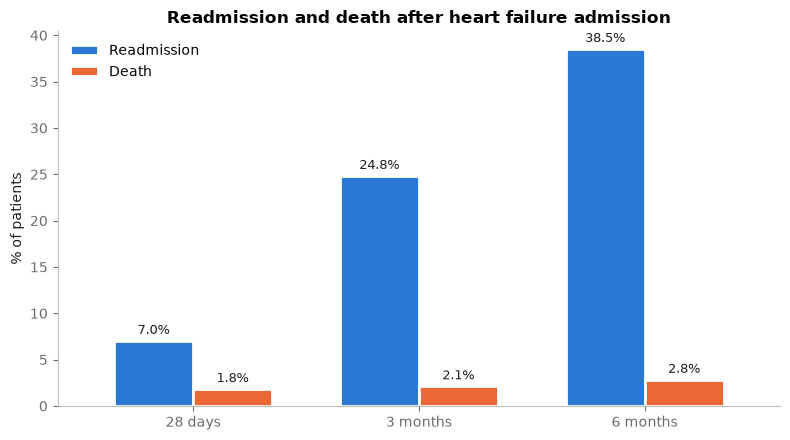

In [3]:
print(df["outcome_during_hospitalization"].value_counts(), "\n")
windows = ["28_days", "3_months", "6_months"]
rates = pd.DataFrame({
    "Readmission": [df[f"re_admission_within_{w}"].mean() * 100 for w in windows],
    "Death":       [df[f"death_within_{w}"].mean() * 100 for w in windows],
}, index=["28 days", "3 months", "6 months"]).round(1)
print(rates)

fig, ax = plt.subplots(figsize=(8, 4.5))
rates.plot(kind="bar", ax=ax, color=[BLUE, ORANGE], rot=0, width=0.7, edgecolor="white", linewidth=2)
label_bars(ax)
ax.set(ylabel="% of patients", title="Readmission and death after heart failure admission")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Only 11 patients (0.5%) died in hospital, and 107 left against medical advice. Death stays low (2.8% by 6 months), but readmission climbs fast: 7% at 28 days, 25% at 3 months and 38.5% at 6 months. In this group of patients, <b>readmission is the bigger problem</b>, and it is the main outcome to explain in the prescriptive and predictive sections.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q2. What is the demographic and body-composition profile of the patients?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>"agecat","gender","weight","height","bmi","bmi_category","obesity_flag"
</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>
The original analysis examined age, gender and BMI because these variables describe the basic demographic profile of the heart-failure population. 
    Since weight and height were cleaned and BMI was recalculated during data cleaning, the analysis can use both the continuous BMI measurement and BMI categories rather than relying only on a categorical BMI variable. 
    xamining these variables together provides a clearer description of the population's age structure, gender composition and body-composition profile.</b></i></p>

Age distribution (%)


,Percent
agecat,
21-29,0.2
29-39,0.6
39-49,2.8
49-59,5.3
59-69,18.3
69-79,35.6
79-89,32.2
89-110,5.0


Gender distribution (%)


,Percent
gender,
Female,57.9
Male,42.1


BMI category distribution (%)


,Percent
bmi_category,
Normal,59.2
Underweight,25.4
Overweight,12.2
Obese,3.3


BMI summary by gender


,patients,median,mean,q1,q3
gender,,,,,
Female,1158,20.56,21.16,18.31,23.43
Male,842,20.81,21.48,18.73,23.52


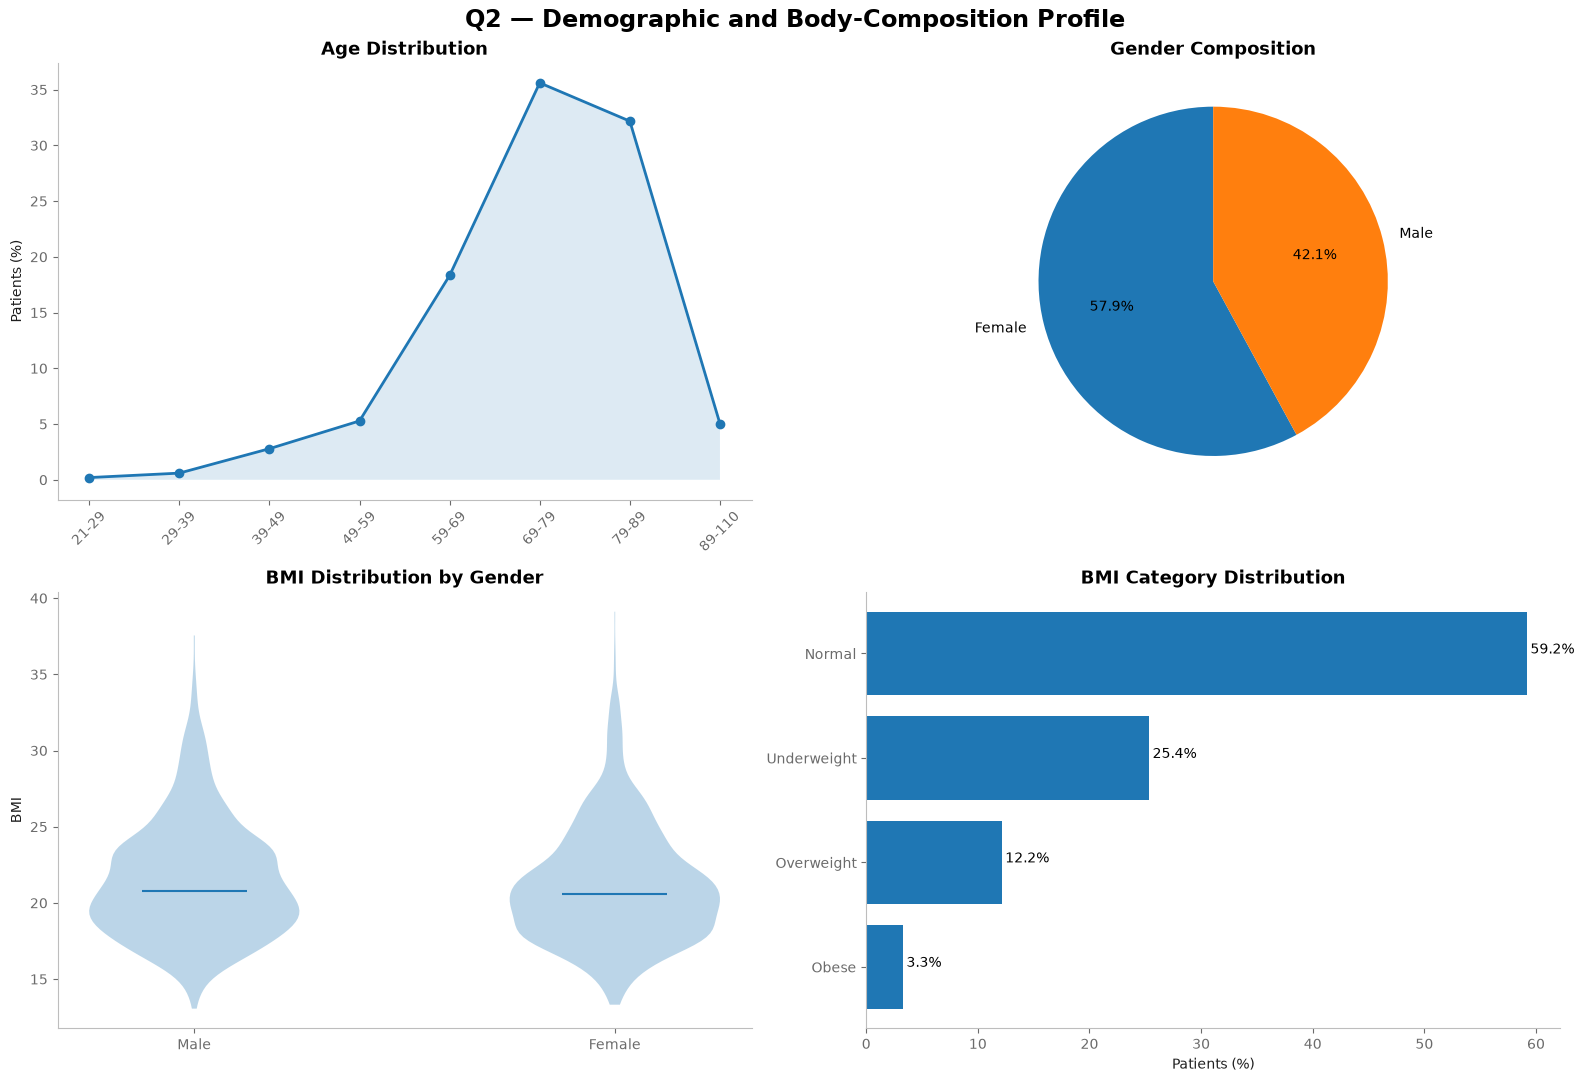

In [4]:
# ============================================================
#  Demographic and Body-Composition Profile
# ============================================================

q2_cols = ["agecat", "gender","weight","height","bmi","bmi_category","obesity_flag"]

q2 = df[q2_cols].copy()

# ------------------------------------------------------------
# 1. Age distribution
# ------------------------------------------------------------

age_order = ["21-29","29-39","39-49","49-59","59-69","69-79","79-89","89-110"]

age_pct = (
    q2["agecat"]
    .value_counts(normalize=True)
    .reindex(age_order)
    .fillna(0)
    * 100
)

# ------------------------------------------------------------
# 2. Gender distribution
# ------------------------------------------------------------

gender_pct = (
    q2["gender"]
    .value_counts(normalize=True)
    * 100
)

# ------------------------------------------------------------
# 3. BMI category distribution
# ------------------------------------------------------------

bmi_category_pct = (
    q2["bmi_category"]
    .value_counts(normalize=True)
    * 100
)

# ------------------------------------------------------------
# 4. BMI distribution by gender
# ------------------------------------------------------------

bmi_gender = [
    q2.loc[
        q2["gender"] == gender,
        "bmi"
    ].dropna()
    for gender in q2["gender"].dropna().unique()
]

gender_labels = q2["gender"].dropna().unique()

# ------------------------------------------------------------
# Display summary tables
# ------------------------------------------------------------

print("Age distribution (%)")
display(age_pct.round(1).to_frame("Percent"))
print("Gender distribution (%)")
display(gender_pct.round(1).to_frame("Percent"))
print("BMI category distribution (%)")
display(bmi_category_pct.round(1).to_frame("Percent"))
print("BMI summary by gender")
display(
    q2.groupby("gender")["bmi"]
    .agg(
        patients="count",median="median",mean="mean",q1=lambda x: x.quantile(0.25),q3=lambda x: x.quantile(0.75))
    .round(2))

# ============================================================
#  visualization 
# Age distribution + BMI distribution + BMI categories
# ============================================================

fig, axes = plt.subplots(2, 2,figsize=(16, 11))

# ------------------------------------------------------------
# A. Age profile
# ------------------------------------------------------------

axes[0, 0].plot(age_pct.index,age_pct.values,marker="o", linewidth=2)
axes[0, 0].fill_between(range(len(age_pct)),age_pct.values, alpha=0.15)
axes[0, 0].set_title("Age Distribution",fontsize=13,fontweight="bold")
axes[0, 0].set_ylabel("Patients (%)")
axes[0, 0].tick_params(axis="x",rotation=45)
# ------------------------------------------------------------
# B. Gender composition
# ------------------------------------------------------------
axes[0, 1].pie(gender_pct.values,labels=gender_pct.index, autopct="%1.1f%%",startangle=90)
axes[0, 1].set_title("Gender Composition", fontsize=13,fontweight="bold")

# ------------------------------------------------------------
# C. BMI distribution by gender
# ------------------------------------------------------------

axes[1, 0].violinplot(bmi_gender, showmedians=True,showextrema=False)
axes[1, 0].set_xticks(range(1, len(gender_labels) + 1), gender_labels)
axes[1, 0].set_ylabel("BMI")
axes[1, 0].set_title( "BMI Distribution by Gender",fontsize=13,fontweight="bold")

# ------------------------------------------------------------
# D. BMI categories
# ------------------------------------------------------------
bmi_category_pct = bmi_category_pct.sort_values( ascending=True)
axes[1, 1].barh( bmi_category_pct.index,bmi_category_pct.values)
axes[1, 1].set_xlabel("Patients (%)")
axes[1, 1].set_title("BMI Category Distribution",fontsize=13, fontweight="bold")
for i, value in enumerate(bmi_category_pct.values):
    axes[1, 1].text(value + 0.3,i, f"{value:.1f}%")

plt.suptitle("Q2 — Demographic and Body-Composition Profile",fontsize=17,fontweight="bold")

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Most patients are elderly: 72.8% are 69 or older, and the largest group is 69–79. There are more women (58%) than men (42%). A quarter of patients (25.4%) are underweight and only 3.3% are obese, so <b>low body weight is a bigger concern than obesity</b> here. This may point to frailty or cardiac cachexia in older patients.<b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q3.How severe is heart failure at admission, and what is the cardiac phenotype of the patient population?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code> "nyha_cardiac_function_classification","killip_grade","type_of_heart_failure","lvef",
    "lvedd_mm"</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>NYHA class (1–4) measures how much the patient's daily activity is limited by symptoms, and Killip grade (1–4) measures signs of congestion and shock, such as fluid in the lungs. Doctors use these two scales to judge how sick a heart failure patient is at admission. Looking at them together shows how many patients are in the severe groups.</b></i></p>

NYHA distribution (%)


,Percentage
nyha_cardiac_function_classification,
2,17.6
3,51.7
4,30.7



Killip distribution (%)


,Percentage
killip_grade,
1,26.2
2,51.2
3,19.5
4,3.0



Type of heart failure (%)


,Percentage
type_of_heart_failure,
Both,73.7
Left,23.8
Right,2.5



LVEF summary


,LVEF
count,635.00
mean,50.68
std,13.22
min,5.00
25%,41.00
50%,51.00
75%,61.00
max,82.00



LVEDD summary


,LVEDD (mm)
count,1309.00
mean,53.19
std,10.74
min,22.00
25%,45.00
50%,53.00
75%,60.00
max,88.00


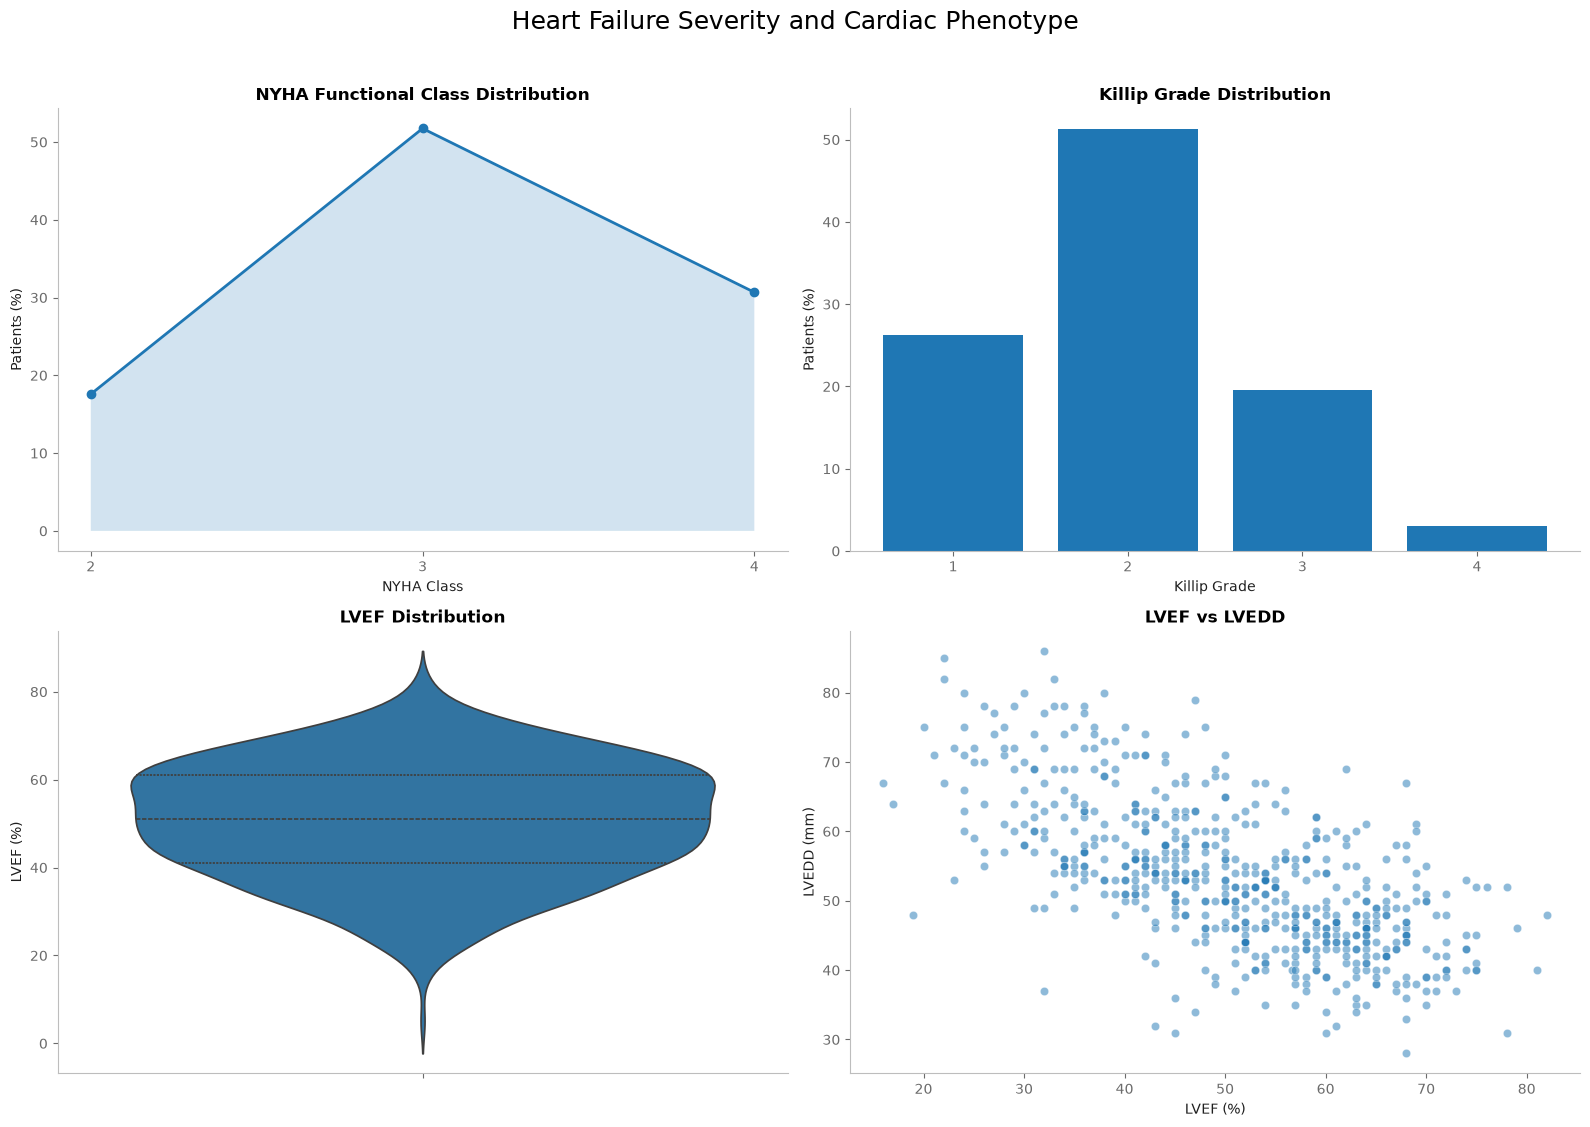


Missingness in cardiac phenotype variables:


,Missing (%)
lvef,68.4
lvedd_mm,34.8
nyha_cardiac_function_classification,0.0
type_of_heart_failure,0.0
killip_grade,0.0


In [5]:
# -----------------------------------------
#  Heart Failure Severity + Cardiac Phenotype
# -----------------------------------------

q3_cols = ["nyha_cardiac_function_classification","killip_grade","type_of_heart_failure","lvef", "lvedd_mm"]

q3 = df[q3_cols].copy()

# -----------------------------
# 1. Severity distributions
# -----------------------------

nyha_pct = (
    q3["nyha_cardiac_function_classification"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .sort_index()
)

killip_pct = (
    q3["killip_grade"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .sort_index()
)

print("NYHA distribution (%)")
display(nyha_pct.round(1).to_frame("Percentage"))

print("\nKillip distribution (%)")
display(killip_pct.round(1).to_frame("Percentage"))


# -----------------------------
# 2. Heart-failure phenotype
# -----------------------------

hf_type_pct = (
    q3["type_of_heart_failure"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
)

print("\nType of heart failure (%)")
display(hf_type_pct.round(1).to_frame("Percentage"))


# -----------------------------
# 3. Cardiac measurements
# -----------------------------

print("\nLVEF summary")
display(
    q3["lvef"]
    .describe()
    .round(2)
    .to_frame("LVEF")
)

print("\nLVEDD summary")
display(
    q3["lvedd_mm"]
    .describe()
    .round(2)
    .to_frame("LVEDD (mm)")
)


# ==========================================
#  VISUALIZATION
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ------------------------------------------
# A. NYHA severity profile
# ------------------------------------------

nyha_plot = nyha_pct.dropna()

axes[0, 0].plot(nyha_plot.index.astype(str), nyha_plot.values,marker="o",linewidth=2)
axes[0, 0].fill_between( range(len(nyha_plot)),nyha_plot.values,alpha=0.2)
axes[0, 0].set_title("NYHA Functional Class Distribution")
axes[0, 0].set_xlabel("NYHA Class")
axes[0, 0].set_ylabel("Patients (%)")

# ------------------------------------------
# B. Killip severity profile
# ------------------------------------------

killip_plot = killip_pct.dropna()

axes[0, 1].bar(killip_plot.index.astype(str),killip_plot.values)
axes[0, 1].set_title("Killip Grade Distribution")
axes[0, 1].set_xlabel("Killip Grade")
axes[0, 1].set_ylabel("Patients (%)")

# ------------------------------------------
# C. LVEF distribution
# ------------------------------------------

lvef_data = q3["lvef"].dropna()
sns.violinplot(y=lvef_data,ax=axes[1, 0],inner="quartile")
axes[1, 0].set_title("LVEF Distribution")
axes[1, 0].set_ylabel("LVEF (%)")
axes[1, 0].set_xlabel("")


# ------------------------------------------
# D. LVEF vs LVEDD
# ------------------------------------------

cardiac_plot = q3[["lvef", "lvedd_mm"]].dropna()
sns.scatterplot(data=cardiac_plot,x="lvef",y="lvedd_mm",alpha=0.5,ax=axes[1, 1])
axes[1, 1].set_title("LVEF vs LVEDD")
axes[1, 1].set_xlabel("LVEF (%)")
axes[1, 1].set_ylabel("LVEDD (mm)")
plt.suptitle("Heart Failure Severity and Cardiac Phenotype", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()


# -----------------------------------------
#  phenotype summary
# -----------------------------------------

print("\nMissingness in cardiac phenotype variables:")
display(
    q3.isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .to_frame("Missing (%)")
)

<p style="font-family: Cambria; font-size: 16px;">
<b>Insight</b>
</p>

<p style="font-family: Cambria; font-size: 16px;">
<b><i>
The existing analysis shows that most patients present with advanced heart-failure severity, with approximately 82% classified as NYHA III or IV and a substantial proportion having higher Killip grades. This indicates that the population represents patients with considerable clinical severity at admission.
The cardiac phenotype also shows variation in heart-failure type and ventricular function. LVEF and LVEDD provide complementary information on cardiac function and structure, while the substantial missingness in LVEF should be considered when interpreting the phenotype results.

</i></b>
</p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q4. What do the major heart-failure biomarkers reveal about the patient population?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>"brain_natriuretic_peptide","high_sensitivity_troponin","hs_crp","bnp_at_assay_limit"</code></p>
<p style="font-family: Cambria; font-size: 16px;">
<b>Reasoning</b>
</p>

<p style="font-family: Cambria; font-size: 16px;">
<b><i>

The original analysis examined BNP, high-sensitivity troponin and hs-CRP because these laboratory measurements provide important information about the biochemical profile of the heart-failure population. BNP reflects the burden of heart failure, while troponin and hs-CRP provide additional information about myocardial injury and inflammation.

The cleaning process also identified patients whose BNP was recorded exactly at 5000, suggesting an assay reporting limit. Therefore, the analysis should examine both the distributions of the biomarkers and the proportion of BNP values at this limit rather than treating these extreme values as ordinary measurements.

</i></b>


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,missing_%
brain_natriuretic_peptide,1973.0,1280.44,1354.16,2.69,303.94,753.03,1738.52,3385.09,5000.0,5000.00,5000.0,1.7
high_sensitivity_troponin,1929.0,281.54,1923.46,0.00,23.00,55.00,119.00,295.00,619.4,3816.56,45675.0,3.9
hs_crp,941.0,25.09,34.65,0.10,4.00,9.40,29.80,80.60,104.0,153.60,188.1,53.1


BNP values at assay limit: 100
Percentage of measured BNP at 5000: 5.1%


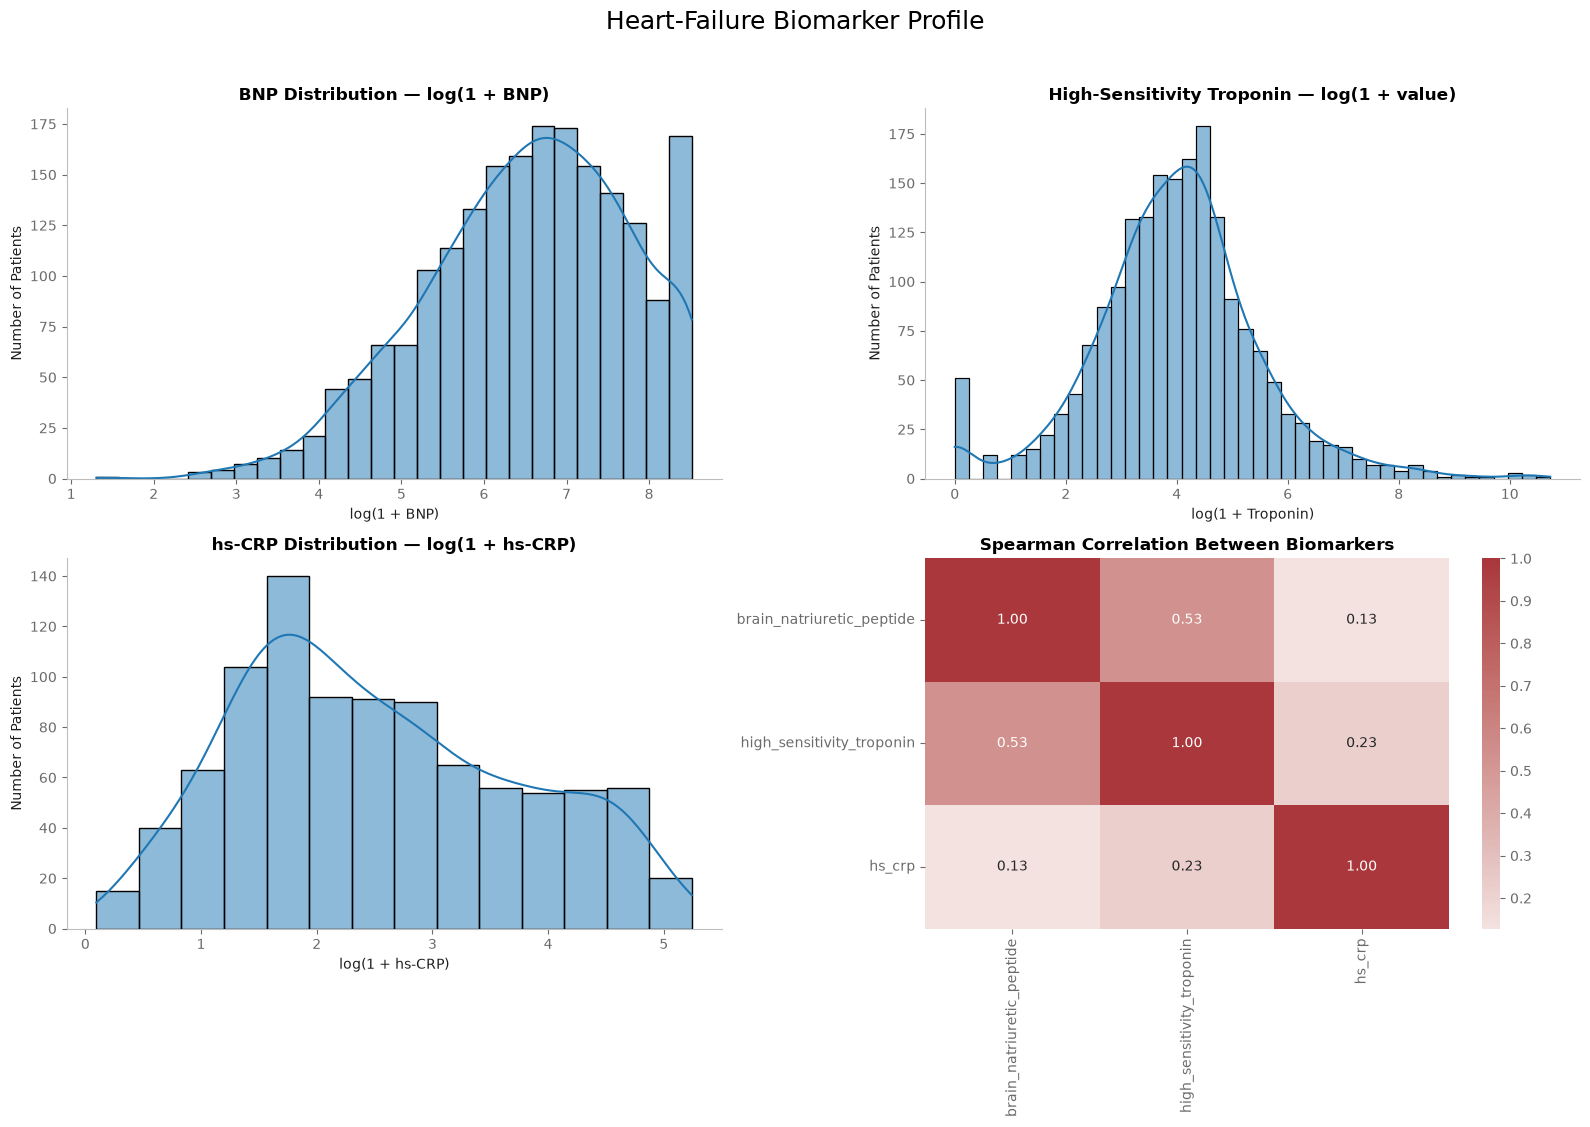


Biomarker missingness:


,Missing (%)
hs_crp,53.1
high_sensitivity_troponin,3.9
brain_natriuretic_peptide,1.7


In [6]:


# -----------------------------------------
# Heart-Failure Biomarker Profile
# -----------------------------------------

q4_cols = ["brain_natriuretic_peptide","high_sensitivity_troponin","hs_crp"]
q4 = df[q4_cols].copy()
# =========================================
# 1. Create BNP assay-limit flag
# =========================================

# BNP = 5000 was identified in the cleaning workflow
# as the assay/reporting limit.
q4["bnp_at_assay_limit"] = (q4["brain_natriuretic_peptide"] == 5000).astype(int)

# =========================================
# 2. Summary statistics
# =========================================

biomarkers = ["brain_natriuretic_peptide", "high_sensitivity_troponin", "hs_crp"]
summary = q4[biomarkers].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T

summary["missing_%"] = (q4[biomarkers].isna().mean() * 100).round(1)

display(summary.round(2))


# =========================================
# 3. BNP assay-limit check
# =========================================

bnp_limit_count = int(q4["bnp_at_assay_limit"].sum())

bnp_available = q4["brain_natriuretic_peptide"].notna().sum()

bnp_limit_pct = (bnp_limit_count / bnp_available * 100
    if bnp_available > 0 else np.nan
)
print(f"BNP values at assay limit: {bnp_limit_count}")
print(f"Percentage of measured BNP at 5000: {bnp_limit_pct:.1f}%")


# =========================================
# 4. Log transformations
# =========================================

plot_data = q4[biomarkers].copy()

for col in biomarkers:
    plot_data[f"log_{col}"] = np.log1p(plot_data[col])


# =========================================
# 5. Advanced visualization
# =========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))


# -----------------------------------------
# A. BNP distribution
# -----------------------------------------

sns.histplot(data=plot_data, x="log_brain_natriuretic_peptide", kde=True, ax=axes[0, 0])

axes[0, 0].set_title("BNP Distribution — log(1 + BNP)")
axes[0, 0].set_xlabel("log(1 + BNP)")
axes[0, 0].set_ylabel("Number of Patients")


# -----------------------------------------
# B. Troponin distribution
# -----------------------------------------

sns.histplot(data=plot_data,x="log_high_sensitivity_troponin",kde=True,ax=axes[0, 1])
axes[0, 1].set_title("High-Sensitivity Troponin — log(1 + value)")
axes[0, 1].set_xlabel("log(1 + Troponin)")
axes[0, 1].set_ylabel("Number of Patients")


# -----------------------------------------
# C. hs-CRP distribution
# -----------------------------------------

sns.histplot( data=plot_data, x="log_hs_crp",kde=True,ax=axes[1, 0])

axes[1, 0].set_title("hs-CRP Distribution — log(1 + hs-CRP)")
axes[1, 0].set_xlabel("log(1 + hs-CRP)")
axes[1, 0].set_ylabel("Number of Patients")


# -----------------------------------------
# D. Biomarker correlation
# -----------------------------------------

corr_data = q4[biomarkers].corr(method="spearman")

sns.heatmap(corr_data,annot=True,fmt=".2f",cmap="vlag", center=0,ax=axes[1, 1])
axes[1, 1].set_title("Spearman Correlation Between Biomarkers")
plt.suptitle("Heart-Failure Biomarker Profile",fontsize=18, y=1.02)

plt.tight_layout()
plt.show()


# =========================================
# 6. Missingness
# =========================================

missing_pct = (
    q4[biomarkers]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\nBiomarker missingness:")
display(
    missing_pct.round(1).to_frame("Missing (%)")
)

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b><div style="font-family: Cambria; font-size: 16px;">



The biomarker profile shows substantial biochemical evidence of heart-failure burden, with the original analysis finding elevated BNP in most patients and high-sensitivity troponin elevated in a large proportion of measured patients. hs-CRP also indicates an inflammatory component among patients who were tested.

BNP values at the assay limit of 5000 should be interpreted separately because the exact value may represent a reporting ceiling rather than the patient's true maximum concentration. Missingness also differs across biomarkers and should be considered when comparing their distributions.

</i></b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q5.What is the kidney function and anemia profile of the patients?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:"glomerular_filtration_rate","hemoglobin","gender"</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The original analysis treated kidney function and anemia as two separate descriptive questions. Combining them gives a broader view of two important non-cardiac clinical characteristics of the patient population while keeping the analysis focused and clinically interpretable.

Kidney function is described using glomerular filtration rate, while hemoglobin provides the basis for describing anemia.
    Gender is retained because the original analysis examined anemia separately by gender. 
The analysis should also show the amount of missing information rather than assuming that an unrecorded laboratory result represents a normal value.</i></p>

Kidney Function — eGFR Summary


,glomerular_filtration_rate
count,1945.00
mean,68.66
std,36.61
min,3.13
25%,41.60
50%,64.79
75%,90.12
max,281.01


eGFR Group Distribution (%)


,percentage
egfr_group,
30–59,31.6
60–89,28.3
≥90,24.5
<30,12.5
NaN,3.1


Hemoglobin Summary


,hemoglobin
count,1980.00
mean,115.07
std,24.53
min,29.00
25%,101.00
50%,117.00
75%,131.00
max,200.00


Hemoglobin by Gender


,count,mean,median,std
gender,,,,
Female,1149,110.81,114.0,23.78
Male,831,120.95,122.0,24.35


Missing Information (%)


,missing_%
glomerular_filtration_rate,3.1
hemoglobin,1.4
gender,0.0


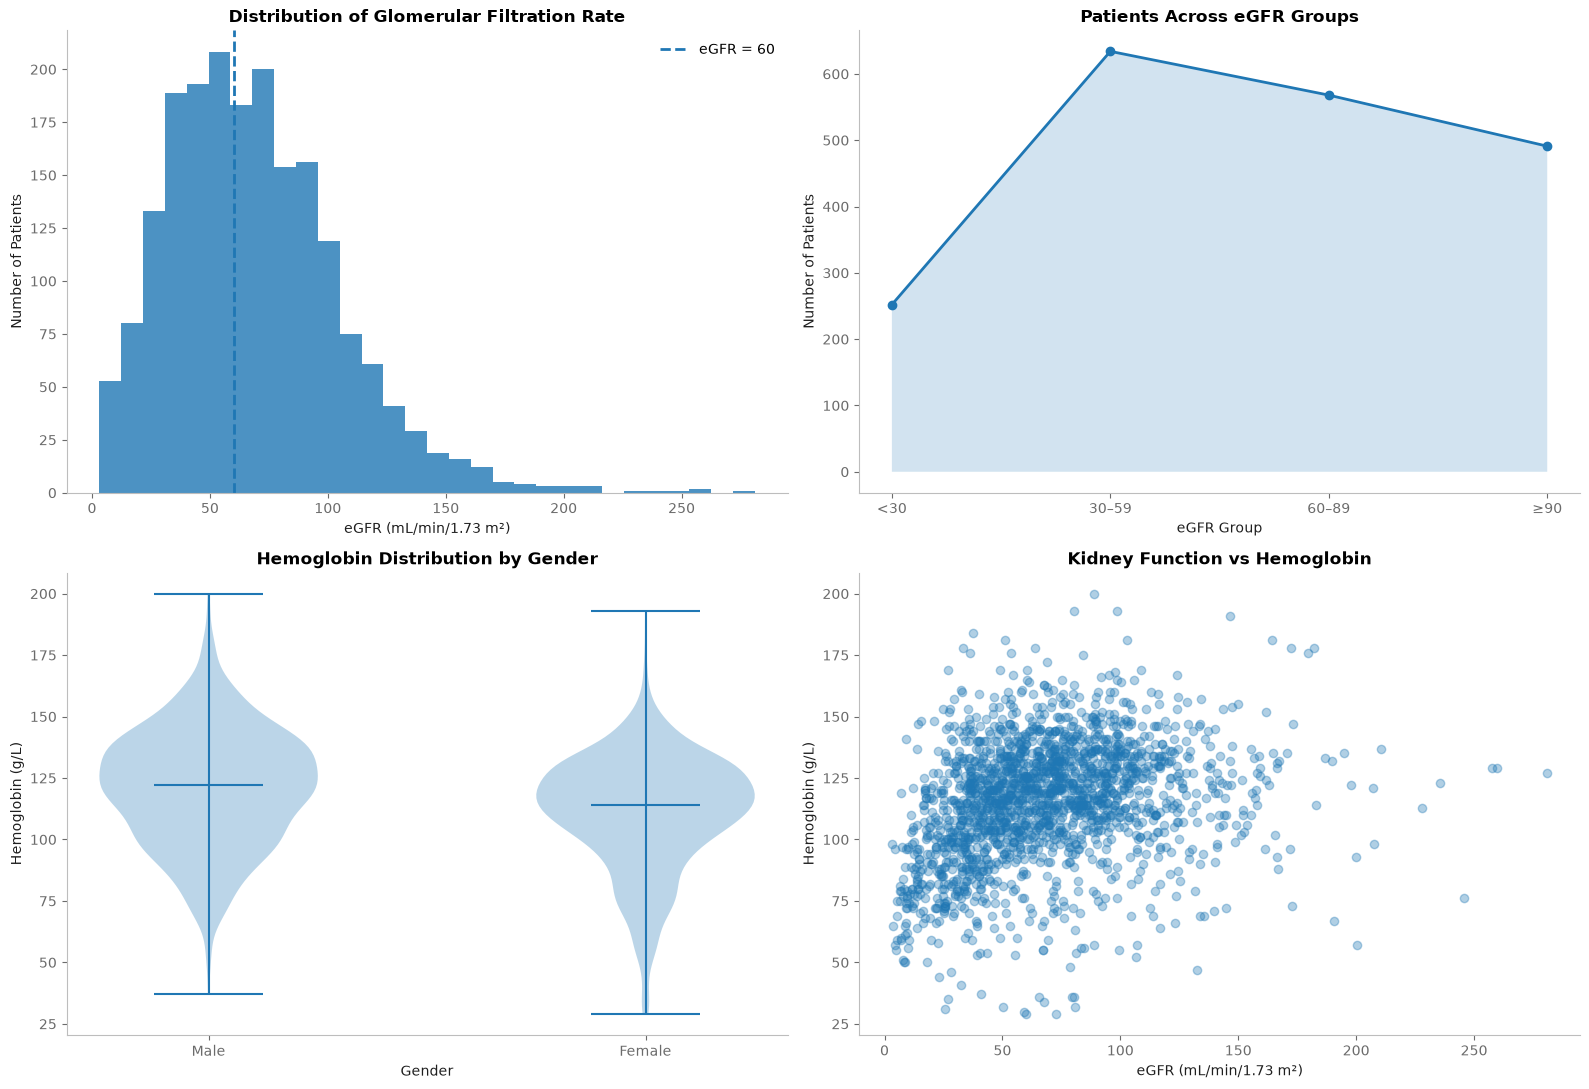

In [7]:
# ============================================================
#  Kidney Function + Anemia
# ============================================================

q5_cols = ["glomerular_filtration_rate","hemoglobin","gender"]
q5 = df[q5_cols].copy()

# ------------------------------------------------------------
# 1. Kidney function summary
# ------------------------------------------------------------

gfr_summary = q5["glomerular_filtration_rate"].describe()

print("Kidney Function — eGFR Summary")
display(gfr_summary.to_frame().round(2))


# Create descriptive eGFR groups for visualization
q5["egfr_group"] = pd.cut(q5["glomerular_filtration_rate"], bins=[-float("inf"), 30, 60, 90, float("inf")], labels=["<30", "30–59", "60–89", "≥90"])

egfr_distribution = (
    q5["egfr_group"]
    .value_counts(dropna=False, normalize=True)
    .mul(100)
    .round(1)
    .rename("percentage")
    .to_frame()
)

print("eGFR Group Distribution (%)")
display(egfr_distribution)


# ------------------------------------------------------------
# 2. Hemoglobin summary
# ------------------------------------------------------------

hemoglobin_summary = q5["hemoglobin"].describe()

print("Hemoglobin Summary")
display(hemoglobin_summary.to_frame().round(2))


# ------------------------------------------------------------
# 3. Hemoglobin distribution by gender
# ------------------------------------------------------------

hb_by_gender = (
    q5.groupby("gender", observed=True)["hemoglobin"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

print("Hemoglobin by Gender")
display(hb_by_gender)


# ------------------------------------------------------------
# 4. Missingness
# ------------------------------------------------------------

q5_missing = (
    q5[["glomerular_filtration_rate", "hemoglobin", "gender"]]
    .isna()
    .mean()
    .mul(100)
    .round(1)
    .rename("missing_%")
    .to_frame()
)

print("Missing Information (%)")
display(q5_missing)


# ============================================================
#  Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ------------------------------------------------------------
# A. eGFR distribution
# ------------------------------------------------------------

axes[0, 0].hist(q5["glomerular_filtration_rate"].dropna(),bins=30,alpha=0.8)
axes[0, 0].axvline(60,linestyle="--",linewidth=2,label="eGFR = 60")
axes[0, 0].set_title("Distribution of Glomerular Filtration Rate")
axes[0, 0].set_xlabel("eGFR (mL/min/1.73 m²)")
axes[0, 0].set_ylabel("Number of Patients")
axes[0, 0].legend()

# ------------------------------------------------------------
# B. eGFR groups
# ------------------------------------------------------------

egfr_plot = (
    q5["egfr_group"]
    .value_counts()
    .sort_index()
)

axes[0, 1].plot(egfr_plot.index.astype(str),egfr_plot.values, marker="o",linewidth=2)
axes[0, 1].fill_between(range(len(egfr_plot)),egfr_plot.values, alpha=0.2)
axes[0, 1].set_title("Patients Across eGFR Groups")
axes[0, 1].set_xlabel("eGFR Group")
axes[0, 1].set_ylabel("Number of Patients")


# ------------------------------------------------------------
# C. Hemoglobin distribution by gender
# ------------------------------------------------------------

hb_gender_data = [
    q5.loc[q5["gender"] == gender, "hemoglobin"].dropna()
    for gender in q5["gender"].dropna().unique()
]

hb_gender_labels = [
    str(gender)
    for gender in q5["gender"].dropna().unique()
]

axes[1, 0].violinplot(hb_gender_data,showmedians=True)
axes[1, 0].set_xticks(range(1, len(hb_gender_labels) + 1))
axes[1, 0].set_xticklabels(hb_gender_labels)
axes[1, 0].set_title("Hemoglobin Distribution by Gender")
axes[1, 0].set_xlabel("Gender")
axes[1, 0].set_ylabel("Hemoglobin (g/L)")


# ------------------------------------------------------------
# D. Kidney function vs hemoglobin
# ------------------------------------------------------------

scatter_data = q5.dropna(subset=["glomerular_filtration_rate","hemoglobin"])
axes[1, 1].scatter(scatter_data["glomerular_filtration_rate"],scatter_data["hemoglobin"],alpha=0.35)
axes[1, 1].set_title("Kidney Function vs Hemoglobin")
axes[1, 1].set_xlabel("eGFR (mL/min/1.73 m²)")
axes[1, 1].set_ylabel("Hemoglobin (g/L)")
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The original analysis found that a substantial proportion of patients had reduced kidney function, 
with approximately 44% having eGFR below 60 mL/min/1.73 m².The anemia analysis also identified anemia as a common finding, affecting approximately 61% of patients in the original results.
    Together, kidney function and hemoglobin describe important additional clinical burden in this population. 
        Differences in missing laboratory measurements should be considered when interpreting the distributions, rather than treating missing results as normal values.</i></b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q6. What is the admission hemodynamic and respiratory profile of the patients?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>"systolic_blood_pressure","diastolic_blood_pressure","map_value", "pulse","respiration","respiratory_support",
    "type_ii_respiratory_failure","bp_category"
</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The original analysis examined admission blood pressure to describe the hemodynamic profile of the patient population.
    The cleaning process also verified that zero values for pulse, respiration and blood pressure were treated as missing and that systolic blood pressure was not lower than diastolic pressure.
To make the descriptive analysis more complete, respiratory characteristics are included alongside blood pressure, pulse and respiration. Respiratory support and type II respiratory failure provide 
additional information about the respiratory status of patients at admission</i></p>

Admission Hemodynamic and Respiratory Measurements


,count,mean,std,min,25%,50%,75%,max
systolic_blood_pressure,2003.0,131.29,24.21,50.00,113.00,130.00,147.00,252.00
diastolic_blood_pressure,2003.0,76.66,14.14,30.00,66.00,76.00,85.00,146.00
map_value,2003.0,94.87,15.92,36.67,83.33,93.33,104.67,181.33
pulse,2007.0,85.28,21.46,32.00,70.00,82.00,98.00,198.00
respiration,2007.0,19.10,1.68,15.00,18.00,19.00,19.00,36.00


Blood Pressure Category Distribution (%)


,percentage
bp_category,
Normal,57.2
High,41.5
Low,1.0
NaN,0.2


Respiratory Support Distribution (%)


,percentage
respiratory_support,
Unknown,97.9
IMV,1.2
NIMV,0.8


Type II Respiratory Failure Distribution (%)


,percentage
type_ii_respiratory_failure,
0,94.3
1,5.7


Missing Information (%)


,missing_%
systolic_blood_pressure,0.2
diastolic_blood_pressure,0.2
map_value,0.2
pulse,0.0
respiration,0.0
respiratory_support,97.9
type_ii_respiratory_failure,0.0


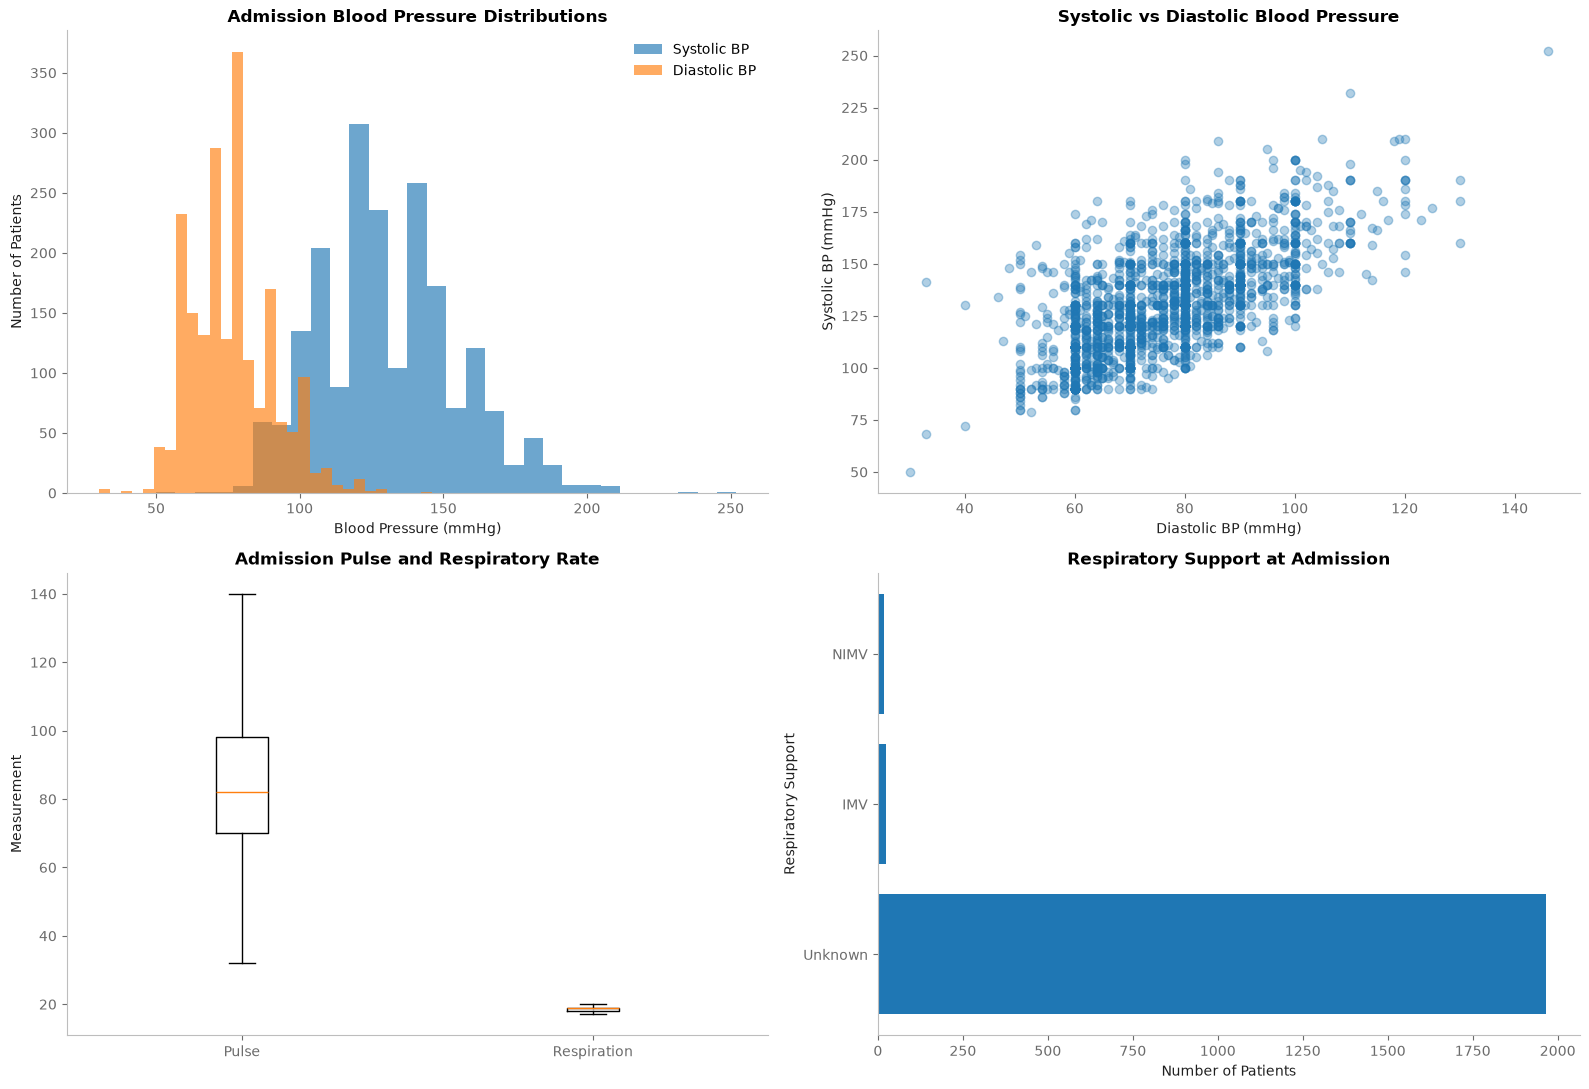

In [8]:
# ============================================================
# Hemodynamic + Respiratory Profile
# ============================================================

q6_cols = ["systolic_blood_pressure","diastolic_blood_pressure","map_value","pulse","respiration","respiratory_support",
           "type_ii_respiratory_failure","bp_category"]
q6 = df[q6_cols].copy()

# ------------------------------------------------------------
# 1. Hemodynamic summary
# ------------------------------------------------------------

vital_summary = q6[
    ["systolic_blood_pressure","diastolic_blood_pressure","map_value","pulse","respiration"]].describe().T.round(2)

print("Admission Hemodynamic and Respiratory Measurements")
display(vital_summary)

# ------------------------------------------------------------
# 2. Blood-pressure categories
# ------------------------------------------------------------


bp_distribution = (
    q6["bp_category"]
    .value_counts(dropna=False, normalize=True)
    .mul(100)
    .round(1)
    .rename("percentage")
    .to_frame()
)

print("Blood Pressure Category Distribution (%)")
display(bp_distribution)


# ------------------------------------------------------------
# 3. Respiratory support distribution
# ------------------------------------------------------------

resp_support_distribution = (
    q6["respiratory_support"]
    .fillna("Unknown")
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .rename("percentage")
    .to_frame()
)

print("Respiratory Support Distribution (%)")
display(resp_support_distribution)


# ------------------------------------------------------------
# 4. Type II respiratory failure
# ------------------------------------------------------------

type2_distribution = (
    q6["type_ii_respiratory_failure"]
    .value_counts(dropna=False, normalize=True)
    .mul(100)
    .round(1)
    .rename("percentage")
    .to_frame()
)

print("Type II Respiratory Failure Distribution (%)")
display(type2_distribution)


# ------------------------------------------------------------
# 5. Missingness
# ------------------------------------------------------------

q6_missing = (
    q6[
        [
            "systolic_blood_pressure",
            "diastolic_blood_pressure",
            "map_value",
            "pulse",
            "respiration",
            "respiratory_support",
            "type_ii_respiratory_failure"
        ]
    ]
    .isna()
    .mean()
    .mul(100)
    .round(1)
    .rename("missing_%")
    .to_frame()
)
print("Missing Information (%)")
display(q6_missing)


# ============================================================
# Advanced Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ------------------------------------------------------------
# A. SBP and DBP distribution
# ------------------------------------------------------------

axes[0, 0].hist(q6["systolic_blood_pressure"].dropna(),bins=30,alpha=0.65,label="Systolic BP")
axes[0, 0].hist(q6["diastolic_blood_pressure"].dropna(),bins=30,alpha=0.65,label="Diastolic BP")
axes[0, 0].set_title("Admission Blood Pressure Distributions")
axes[0, 0].set_xlabel("Blood Pressure (mmHg)")
axes[0, 0].set_ylabel("Number of Patients")
axes[0, 0].legend()


# ------------------------------------------------------------
# B. Blood pressure relationship
# ------------------------------------------------------------

bp_plot = q6.dropna(subset=[ "systolic_blood_pressure", "diastolic_blood_pressure"])
axes[0, 1].scatter( bp_plot["diastolic_blood_pressure"],bp_plot["systolic_blood_pressure"], alpha=0.35)
axes[0, 1].set_title("Systolic vs Diastolic Blood Pressure")
axes[0, 1].set_xlabel("Diastolic BP (mmHg)")
axes[0, 1].set_ylabel("Systolic BP (mmHg)")


# ------------------------------------------------------------
# C. Respiratory measurements
# ------------------------------------------------------------

resp_data = [q6["pulse"].dropna(), q6["respiration"].dropna()]

axes[1, 0].boxplot( resp_data,tick_labels=["Pulse", "Respiration"],showfliers=False)
axes[1, 0].set_title( "Admission Pulse and Respiratory Rate")
axes[1, 0].set_ylabel("Measurement")


# ------------------------------------------------------------
# D. Respiratory support
# ------------------------------------------------------------

support_counts = (
    q6["respiratory_support"]
    .fillna("Unknown")
    .value_counts()
)

axes[1, 1].barh(support_counts.index.astype(str),support_counts.values)
axes[1, 1].set_title("Respiratory Support at Admission")
axes[1, 1].set_xlabel( "Number of Patients")
axes[1, 1].set_ylabel( "Respiratory Support")

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b> The original analysis found a median admission blood pressure of approximately 130/76 mmHg, 
with a substantial proportion of patients falling into the higher blood-pressure categories and a small proportion having very low systolic pressure. 
    This provides an important overview of the admission hemodynamic profile.Adding respiratory rate, respiratory support and type II respiratory failure shows that the admission profile is not defined by blood pressure alone.
        These variables help describe the respiratory burden and distinguish patients requiring additional respiratory support from those without documented support</i><b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q7. What is the comorbidity landscape and overall disease burden of the patients?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b><code>"diabetes","moderate_to_severe_chronic_kidney_disease","chronic_obstructive_pulmonary_disease",
    "cerebrovascular_disease","myocardial_infarction","type_ii_respiratory_failure","dementia","peripheral_vascular_disease","liver_disease",
    "peptic_ulcer_disease","solid_tumor","acute_renal_failure","cci_score","comorbidity_count"

</code><b><i>leukemia is not included because it was identified as a zero-information column during cleaning and removed</b></i></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b><i>
Heart failure patients may have several additional diseases that contribute to their overall clinical burden.
The original analysis therefore examined individual disease-history variables and the Charlson Comorbidity Index (CCI) to describe the patients' comorbidity profile.
Because comorbidity_count was already created during Feature Engineering, it can be used here to summarize the number of recorded comorbidities 
per patient without creating the column again. Together, individual diseases, comorbidity count and CCI provide complementary views of disease burden.</b></i></p>

Comorbidity Prevalence (%)


,percentage
Acute kidney failure,0.3
Solid tumor,1.9
Peptic ulcer,2.2
Liver disease,4.2
Peripheral vascular disease,5.0
Type II respiratory failure,5.7
Dementia,5.7
Previous heart attack,7.1
Stroke / cerebrovascular,7.5
COPD,11.6


Comorbidity Count Summary


,value
count,2008.00
mean,0.72
std,0.79
min,0.00
25%,0.00
50%,1.00
75%,1.00
max,4.00


Comorbidity Count Distribution (%)


...

,value
count,2003.00
mean,1.86
std,0.96
min,0.00
25%,1.00
50%,2.00
75%,2.00
max,6.00


CCI Score Distribution


,patients
cci_score,
0.0,56
1.0,770
2.0,699
3.0,368
4.0,94
5.0,15
6.0,1
NaN,5


Median CCI: 2.0
CCI >= 3: 23.8 %
Missing Information (%)


,missing_%
diabetes,0.0
moderate_to_severe_chronic_kidney_disease,0.1
chronic_obstructive_pulmonary_disease,0.0
cerebrovascular_disease,0.0
myocardial_infarction,0.0
type_ii_respiratory_failure,0.0
dementia,0.0
peripheral_vascular_disease,0.0
liver_disease,0.0
peptic_ulcer_disease,0.1


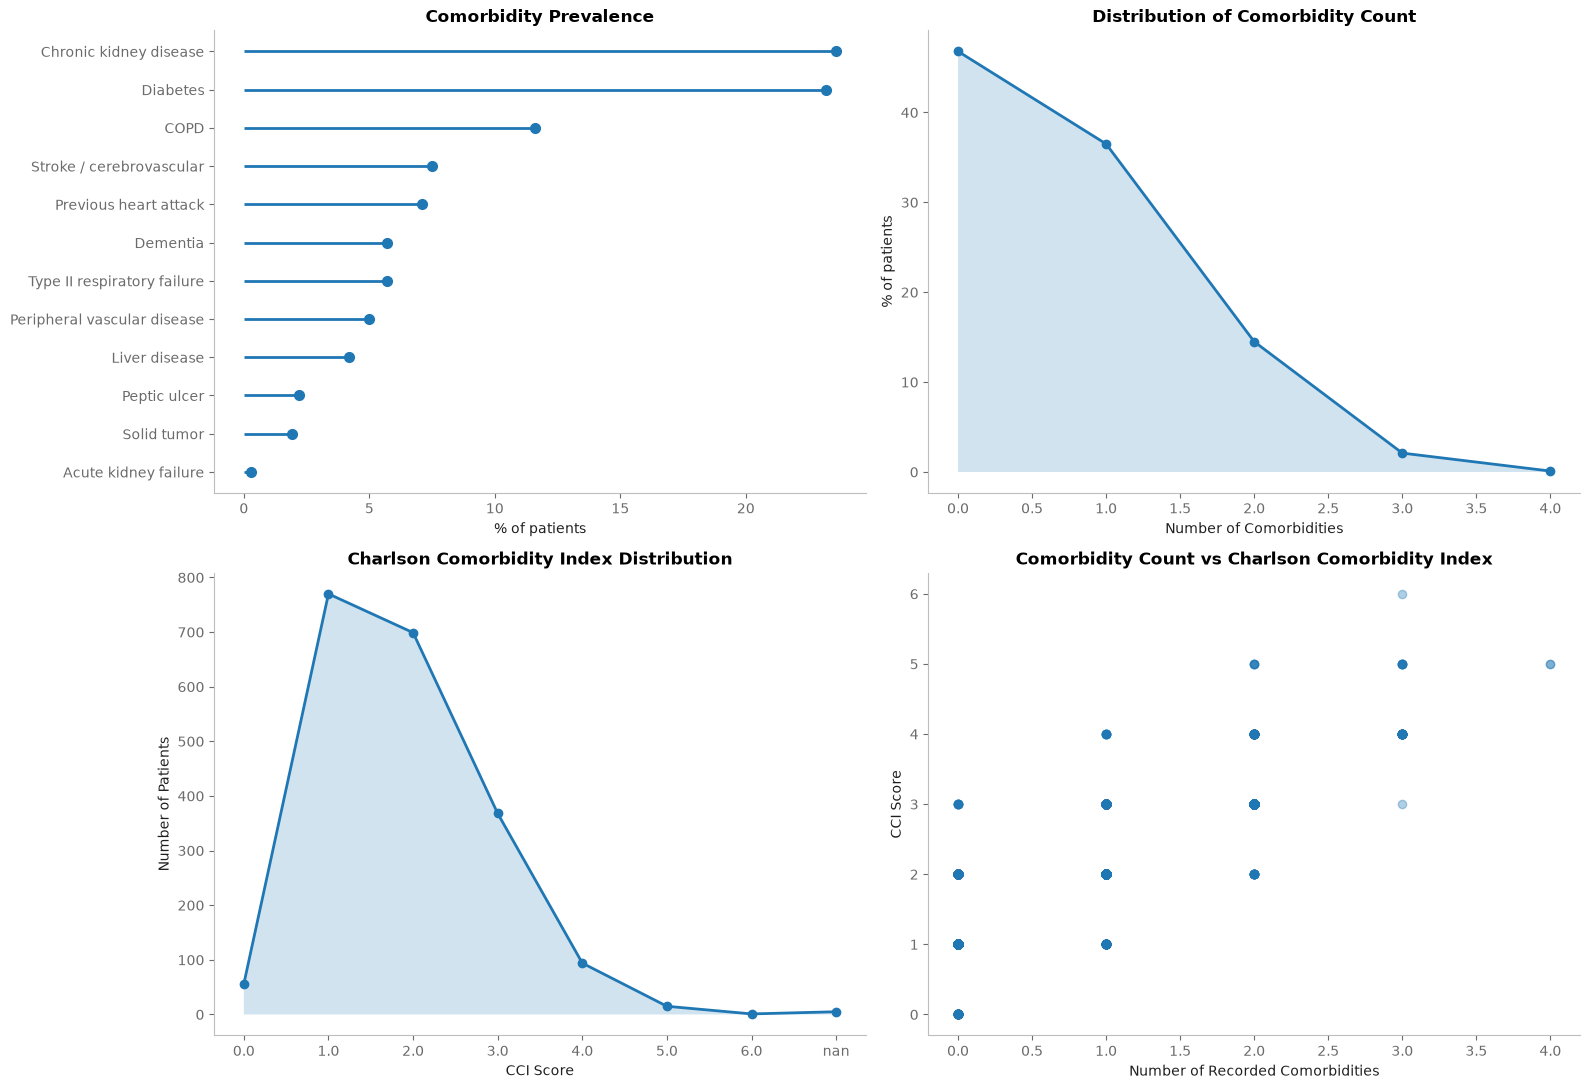

In [9]:
q7_cols = [
    "diabetes","moderate_to_severe_chronic_kidney_disease","chronic_obstructive_pulmonary_disease",
    "cerebrovascular_disease","myocardial_infarction","type_ii_respiratory_failure", "dementia","peripheral_vascular_disease",
    "liver_disease","peptic_ulcer_disease","solid_tumor",
    "acute_renal_failure","cci_score","comorbidity_count"]

q7 = df[q7_cols].copy()


# ------------------------------------------------------------
# 1. Prevalence of individual comorbidities
# ------------------------------------------------------------

disease_cols = ["diabetes","moderate_to_severe_chronic_kidney_disease","chronic_obstructive_pulmonary_disease","cerebrovascular_disease",
    "myocardial_infarction","type_ii_respiratory_failure", "dementia","peripheral_vascular_disease","liver_disease",
    "peptic_ulcer_disease","solid_tumor","acute_renal_failure"]

disease_labels = {"diabetes": "Diabetes","moderate_to_severe_chronic_kidney_disease": "Chronic kidney disease","chronic_obstructive_pulmonary_disease": "COPD",
"cerebrovascular_disease": "Stroke / cerebrovascular","myocardial_infarction": "Previous heart attack", "type_ii_respiratory_failure": "Type II respiratory failure",
 "dementia": "Dementia","peripheral_vascular_disease": "Peripheral vascular disease","liver_disease": "Liver disease","peptic_ulcer_disease": "Peptic ulcer",
 "solid_tumor": "Solid tumor","acute_renal_failure": "Acute kidney failure"}

disease_prevalence = (
    q7[disease_cols]
    .apply(pd.to_numeric, errors="coerce")
    .mean()
    .mul(100)
    .rename(index=disease_labels)
    .sort_values(ascending=True)
    .round(1)
)

print("Comorbidity Prevalence (%)")
display(
    disease_prevalence
    .rename("percentage")
    .to_frame()
)


# ------------------------------------------------------------
# 2. Comorbidity count per patient
# ------------------------------------------------------------

print("Comorbidity Count Summary")
display(
    q7["comorbidity_count"]
    .describe()
    .round(2)
    .to_frame("value")
)

comorbidity_distribution = (
    q7["comorbidity_count"]
    .value_counts(dropna=False)
    .sort_index()
)

comorbidity_percentage = (
    comorbidity_distribution
    .div(len(q7))
    .mul(100)
    .round(1)
    .rename("percentage")
    .to_frame()
)

print("Comorbidity Count Distribution (%)")
display(comorbidity_percentage)


# ------------------------------------------------------------
# 3. Charlson Comorbidity Index
# ------------------------------------------------------------

print("Charlson Comorbidity Index Summary")

display(
    q7["cci_score"]
    .describe()
    .round(2)
    .to_frame("value")
)

cci_distribution = (
    q7["cci_score"]
    .value_counts(dropna=False)
    .sort_index()
)

print("CCI Score Distribution")
display(
    cci_distribution
    .rename("patients")
    .to_frame()
)

print(
    "Median CCI:",
    q7["cci_score"].median()
)

print(
    "CCI >= 3:",
    round(
        (q7["cci_score"] >= 3).mean() * 100,
        1
    ),
    "%"
)


# ------------------------------------------------------------
# 4. Missingness
# ------------------------------------------------------------

q7_missing = (
    q7[
        disease_cols + ["cci_score"]
    ]
    .isna()
    .mean()
    .mul(100)
    .round(1)
    .rename("missing_%")
    .to_frame()
)

print("Missing Information (%)")
display(q7_missing)


# ============================================================
# Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))


# ------------------------------------------------------------
# A. Comorbidity prevalence
# ------------------------------------------------------------

y_pos = range(len(disease_prevalence))

axes[0, 0].hlines(
    y=y_pos,
    xmin=0,
    xmax=disease_prevalence.values,
    linewidth=2
)

axes[0, 0].plot(
    disease_prevalence.values,
    y_pos,
    "o",
    markersize=7
)

axes[0, 0].set_yticks(list(y_pos))
axes[0, 0].set_yticklabels(disease_prevalence.index)
axes[0, 0].set_xlabel("% of patients")
axes[0, 0].set_title("Comorbidity Prevalence")


# ------------------------------------------------------------
# B. Comorbidity count distribution
# ------------------------------------------------------------

count_x = comorbidity_distribution.index.astype(float)
count_y = comorbidity_percentage["percentage"].values

axes[0, 1].plot(
    count_x,
    count_y,
    marker="o",
    linewidth=2
)

axes[0, 1].fill_between(count_x, count_y,alpha=0.2)
axes[0, 1].set_title("Distribution of Comorbidity Count")
axes[0, 1].set_xlabel("Number of Comorbidities")
axes[0, 1].set_ylabel("% of patients")


# ------------------------------------------------------------
# C. CCI distribution
# ------------------------------------------------------------

cci_x = cci_distribution.index.astype(str)
cci_y = cci_distribution.values

axes[1, 0].plot(range(len(cci_y)), cci_y,marker="o",linewidth=2)
axes[1, 0].fill_between( range(len(cci_y)),cci_y,alpha=0.2)
axes[1, 0].set_xticks(range(len(cci_x)))
axes[1, 0].set_xticklabels(cci_x)
axes[1, 0].set_title("Charlson Comorbidity Index Distribution")
axes[1, 0].set_xlabel("CCI Score")
axes[1, 0].set_ylabel("Number of Patients")


# ------------------------------------------------------------
# D. Comorbidity count vs CCI
# ------------------------------------------------------------

cci_plot = q7.dropna( subset=["comorbidity_count", "cci_score"])
axes[1, 1].scatter(cci_plot["comorbidity_count"], cci_plot["cci_score"], alpha=0.35)
axes[1, 1].set_title( "Comorbidity Count vs Charlson Comorbidity Index")
axes[1, 1].set_xlabel("Number of Recorded Comorbidities")
axes[1, 1].set_ylabel( "CCI Score")

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
Chronic kidney disease (24%) and diabetes (23%) are the most common additional diseases, followed by COPD (12%). 
    The median CCI score is 2, and approximately 1 in 4 patients has a CCI score of 3 or more.The comorbidity-count distribution provides an additional patient-level view of how many recorded conditions occur alongside heart failure, 
while CCI summarizes comorbidity burden using the existing clinical index.</i></b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q8.What is the medication landscape across the heart-failure population?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b><b><i> The prescription-derived columns, especially <code>total_drugs</code>, plus the drug-class columns already present in your final dataset</b>,/i></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b> The original analysis examined the medication groups prescribed to patients and the total number of drugs recorded per patient. 
    This is important because the prescription table contains multiple rows for a single patient, so it must first be converted into a patient-level structure for descriptive analysis.
The cleaned prescription features already provide one binary column for each recorded drug and a total_drugs measure. 
    Therefore, this question should use those existing features to describe medication patterns without creating additional medication variables.
    .</b></i></p>

Medication Usage Across Patients (%)


,percentage


Total Recorded Drugs per Patient


,value
count,2008.00
mean,7.65
std,2.43
min,0.00
25%,6.00
50%,8.00
75%,9.00
max,16.00


Medication Count Percentiles


,total_drugs
0.25,6.0
0.50,8.0
0.75,9.0
0.90,11.0
0.95,12.0


Medication Information Missingness (%)


,missing_%
total_drugs,0.0


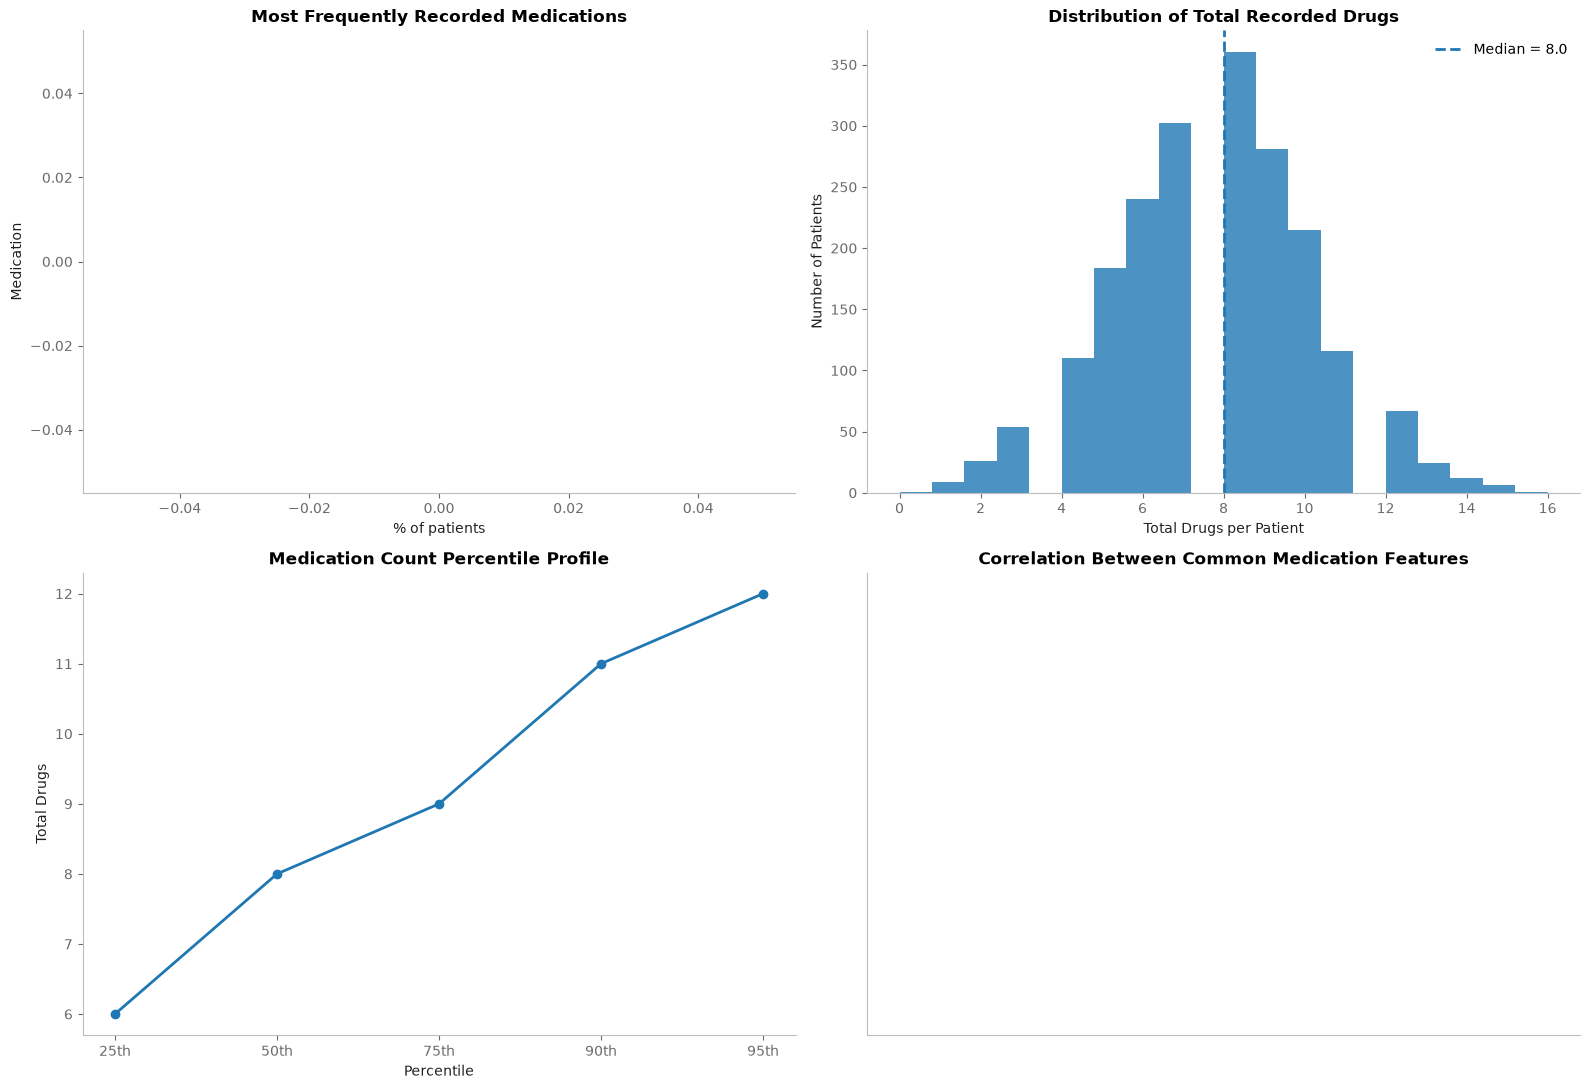

In [10]:
# ============================================================
#  Medication Landscape
# ============================================================

# Existing patient-level prescription features
rx_cols = [c for c in df.columns
    if c.startswith("rx_")
]

q8_cols = rx_cols + ["total_drugs"]

q8 = df[q8_cols].copy()


# ------------------------------------------------------------
# 1. Medication usage across patients
# ------------------------------------------------------------

medication_usage = (
    q8[rx_cols]
    .apply(pd.to_numeric, errors="coerce")
    .mean()
    .mul(100)
    .sort_values(ascending=True)
    .round(1)
)

print("Medication Usage Across Patients (%)")
display(
    medication_usage
    .rename("percentage")
    .to_frame()
)


# ------------------------------------------------------------
# 2. Total drugs summary
# ------------------------------------------------------------

print("Total Recorded Drugs per Patient")

display(
    q8["total_drugs"]
    .describe()
    .round(2)
    .to_frame("value")
)


# ------------------------------------------------------------
# 3. Medication count percentiles
# ------------------------------------------------------------

drug_percentiles = (
    q8["total_drugs"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95])
    .round(1)
    .rename("total_drugs")
    .to_frame()
)

print("Medication Count Percentiles")
display(drug_percentiles)


# ------------------------------------------------------------
# 4. Missingness
# ------------------------------------------------------------

q8_missing = (
    q8
    .isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .rename("missing_%")
    .to_frame()
)

print("Medication Information Missingness (%)")
display(q8_missing.head(15))


# ============================================================
# Advanced Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))


# ------------------------------------------------------------
# A. Most common medication features
# ------------------------------------------------------------

top_medications = medication_usage.tail(10)

axes[0, 0].plot(top_medications.values,top_medications.index,marker="o",linewidth=2)
axes[0, 0].set_title("Most Frequently Recorded Medications")
axes[0, 0].set_xlabel( "% of patients")
axes[0, 0].set_ylabel("Medication")


# ------------------------------------------------------------
# B. Distribution of number of drugs
# ------------------------------------------------------------

axes[0, 1].hist(q8["total_drugs"].dropna(), bins=20,alpha=0.8)
axes[0, 1].axvline( q8["total_drugs"].median(),linestyle="--", linewidth=2, label=f"Median = {q8['total_drugs'].median():.1f}")
axes[0, 1].set_title( "Distribution of Total Recorded Drugs")
axes[0, 1].set_xlabel("Total Drugs per Patient")
axes[0, 1].set_ylabel( "Number of Patients")
axes[0, 1].legend()


# ------------------------------------------------------------
# C. Medication count percentile profile
# ------------------------------------------------------------

axes[1, 0].plot(["25th", "50th", "75th", "90th", "95th"],drug_percentiles["total_drugs"].values,marker="o",linewidth=2)
axes[1, 0].set_title("Medication Count Percentile Profile")
axes[1, 0].set_xlabel("Percentile")
axes[1, 0].set_ylabel("Total Drugs")


# ------------------------------------------------------------
# D. Medication pattern correlation
# ------------------------------------------------------------

top_rx_cols = medication_usage.tail(8).index

corr_matrix = (
    q8[top_rx_cols]
    .corr()
)

im = axes[1, 1].imshow(corr_matrix, aspect="auto")

axes[1, 1].set_title("Correlation Between Common Medication Features")
axes[1, 1].set_xticks(range(len(top_rx_cols)))
axes[1, 1].set_yticks(range(len(top_rx_cols)))
axes[1, 1].set_xticklabels(top_rx_cols,rotation=90)
axes[1, 1].set_yticklabels( top_rx_cols)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>
The original analysis found extensive medication use across the heart-failure population, 
with diuretics and spironolactone among the most frequently recorded medication groups and a high median number of medications per patient.
The medication distribution also shows substantial variation in treatment patterns across patients.
These results describe recorded prescribing patterns rather than judging whether a particular medication combination was clinically appropriate</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q9. How does medication burden vary across the patient population?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code> "total_drugs","medication_burden","polypharmacy_flag"</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The previous question describes the medication groups recorded across the population, 
while medication burden focuses on the number of recorded drugs for each patient. 
The prescription preparation step already created total_drugs, allowing medication load to be studied at the patient level without duplicating patients.
The Feature Engineering step also created medication_burden and polypharmacy_flag, so these existing variables can be used directly to describe how medication use is distributed across patients</b></i></p>

Medication Burden — Summary


,value
count,2008.00
mean,7.65
std,2.43
min,0.00
25%,6.00
50%,8.00
75%,9.00
max,16.00


Medication Burden Distribution (%)


,percentage
medication_burden,
High,90.0
Low,9.9
NaN,0.0


Polypharmacy Distribution (%)


,percentage
polypharmacy_flag,
0,10.0
1,90.0


Medication Count Percentiles


,total_drugs
0.25,6.0
0.50,8.0
0.75,9.0
0.90,11.0
0.95,12.0


Medication Burden Missingness (%)


,missing_%
total_drugs,0.0
medication_burden,0.0
polypharmacy_flag,0.0


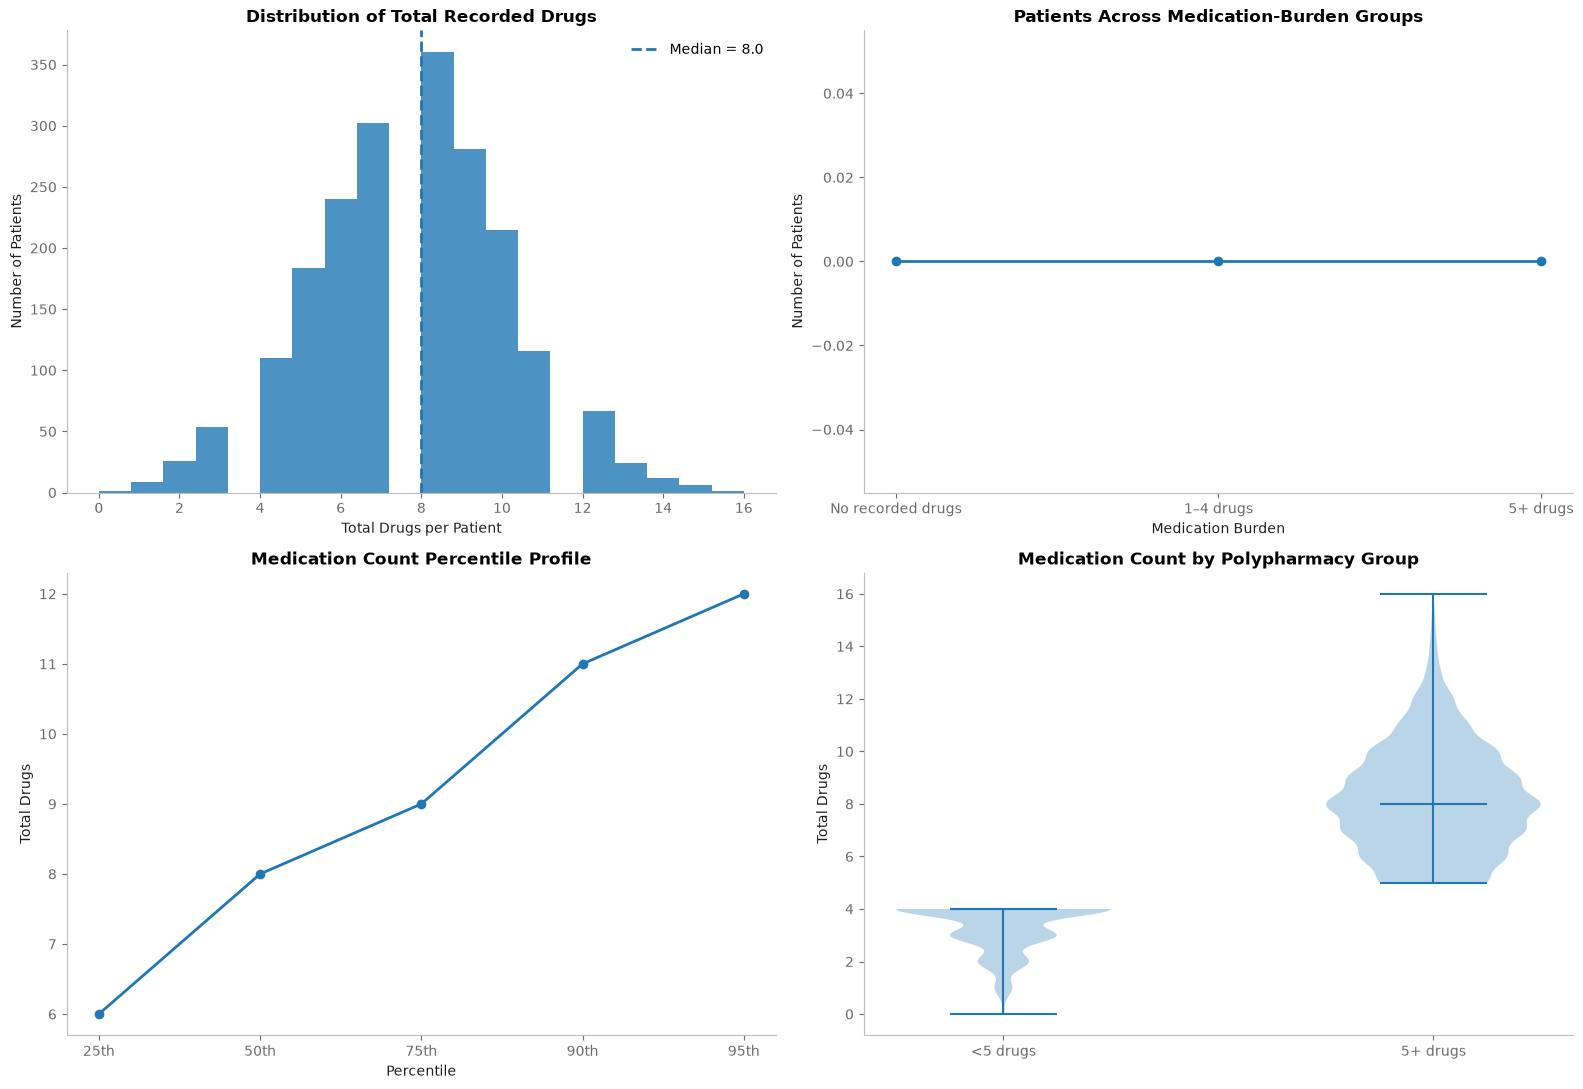

In [11]:
# ============================================================
#  Medication Burden
# ============================================================

q9_cols = ["total_drugs","medication_burden","polypharmacy_flag"]
q9 = df[q9_cols].copy()
# ------------------------------------------------------------
# 1. Total drugs summary
# ------------------------------------------------------------
print("Medication Burden — Summary")
display(
    q9["total_drugs"]
    .describe()
    .round(2)
    .to_frame("value")
)

# ------------------------------------------------------------
# 2. Medication burden distribution
# ------------------------------------------------------------

burden_distribution = (
    q9["medication_burden"]
    .value_counts(dropna=False)
)

burden_percentage = (
    burden_distribution
    .div(len(q9))
    .mul(100)
    .round(1)
    .rename("percentage")
    .to_frame()
)

print("Medication Burden Distribution (%)")
display(burden_percentage)


# ------------------------------------------------------------
# 3. Polypharmacy distribution
# ------------------------------------------------------------

polypharmacy_summary = (
    q9["polypharmacy_flag"]
    .value_counts(dropna=False)
    .sort_index()
)

polypharmacy_percentage = (
    polypharmacy_summary
    .div(len(q9))
    .mul(100)
    .round(1)
    .rename("percentage")
    .to_frame()
)

print("Polypharmacy Distribution (%)")
display(polypharmacy_percentage)


# ------------------------------------------------------------
# 4. Medication count percentiles
# ------------------------------------------------------------

medication_percentiles = (
    q9["total_drugs"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95])
    .round(1)
    .rename("total_drugs")
    .to_frame()
)

print("Medication Count Percentiles")
display(medication_percentiles)


# ------------------------------------------------------------
# 5. Missingness
# ------------------------------------------------------------

q9_missing = (
    q9.isna()
    .mean()
    .mul(100)
    .round(1)
    .rename("missing_%")
    .to_frame()
)

print("Medication Burden Missingness (%)")
display(q9_missing)


# ============================================================
# Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))


# ------------------------------------------------------------
# A. Total drugs distribution
# ------------------------------------------------------------

axes[0, 0].hist( q9["total_drugs"].dropna(),bins=20,alpha=0.8)
axes[0, 0].axvline(q9["total_drugs"].median(),linestyle="--", linewidth=2, label=f"Median = {q9['total_drugs'].median():.1f}")
axes[0, 0].set_title("Distribution of Total Recorded Drugs")
axes[0, 0].set_xlabel("Total Drugs per Patient")
axes[0, 0].set_ylabel( "Number of Patients")
axes[0, 0].legend()


# ------------------------------------------------------------
# B. Medication burden profile
# ------------------------------------------------------------

burden_order = ["No recorded drugs","1–4 drugs","5+ drugs"]

burden_values = (
    burden_distribution
    .reindex(burden_order)
    .fillna(0)
)

axes[0, 1].plot(  burden_order, burden_values.values, marker="o", linewidth=2)
axes[0, 1].fill_between(  range(len(burden_values)), burden_values.values, alpha=0.2)
axes[0, 1].set_title("Patients Across Medication-Burden Groups")
axes[0, 1].set_xlabel("Medication Burden")
axes[0, 1].set_ylabel(  "Number of Patients")


# ------------------------------------------------------------
# C. Medication count percentiles
# ------------------------------------------------------------

axes[1, 0].plot(  ["25th", "50th", "75th", "90th", "95th"], medication_percentiles["total_drugs"].values, marker="o",  linewidth=2)
axes[1, 0].set_title( "Medication Count Percentile Profile")
axes[1, 0].set_xlabel("Percentile")
axes[1, 0].set_ylabel( "Total Drugs")

# ------------------------------------------------------------
# D. Medication count by polypharmacy
# ------------------------------------------------------------

poly_data = [
    q9.loc[
        q9["polypharmacy_flag"] == 0,
        "total_drugs"
    ].dropna(),

    q9.loc[
        q9["polypharmacy_flag"] == 1,
        "total_drugs"
    ].dropna()
]

axes[1, 1].violinplot(poly_data,showmedians=True)
axes[1, 1].set_xticks([1, 2])
axes[1, 1].set_xticklabels(["<5 drugs","5+ drugs"])
axes[1, 1].set_title(  "Medication Count by Polypharmacy Group")
axes[1, 1].set_ylabel( "Total Drugs")

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The original analysis found a high medication burden in this population, 
with a median of approximately 8 recorded drugs per patient and about 90% of patients having five or more recorded drugs.
The percentile and burden distributions show that medication use is not uniform across patients.
 The polypharmacy_flag and medication_burden variables provide an additional summary of this variation.</i></b>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q10.How complete is the clinical information available across the major patient domains?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>  "agecat", "gender",
    "bmi","nyha_cardiac_function_classification", "killip_grade", "lvef", "brain_natriuretic_peptide", "high_sensitivity_troponin",
    "hs_crp","glomerular_filtration_rate","hemoglobin","systolic_blood_pressure", "diastolic_blood_pressure",
    "pulse","respiration","respiratory_support","cci_score", "total_drugs"</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The cleaning process found that missingness has different meanings across this dataset. 
    Some values are structurally missing, while clinical laboratory measurements may be absent because a test was not performed or not recorded. 
        The reference workflow therefore recommends assessing missingness rather than applying blanket imputation.
A final descriptive completeness analysis helps identify which major clinical domains are well represented
and which measurements have substantial missingness before moving into prescriptive and predictive analysis.</i></b></p>

Missing Information by Variable (%)


,missing_%
respiratory_support,97.9
lvef,68.4
hs_crp,53.1
high_sensitivity_troponin,3.9
glomerular_filtration_rate,3.1
brain_natriuretic_peptide,1.7
hemoglobin,1.4
bmi,0.4
cci_score,0.2
systolic_blood_pressure,0.2


Completeness by Variable (%)


,complete_%
respiratory_support,2.1
lvef,31.6
hs_crp,46.9
high_sensitivity_troponin,96.1
glomerular_filtration_rate,96.9
brain_natriuretic_peptide,98.3
hemoglobin,98.6
bmi,99.6
systolic_blood_pressure,99.8
diastolic_blood_pressure,99.8


Average patient-level completeness: 87.2 %
Median patient-level completeness: 88.9 %
Patient-Level Completeness Groups (%)


,percentage
<50% complete,0.0
50–75% complete,1.2
75–90% complete,83.1
90–100% complete,15.7


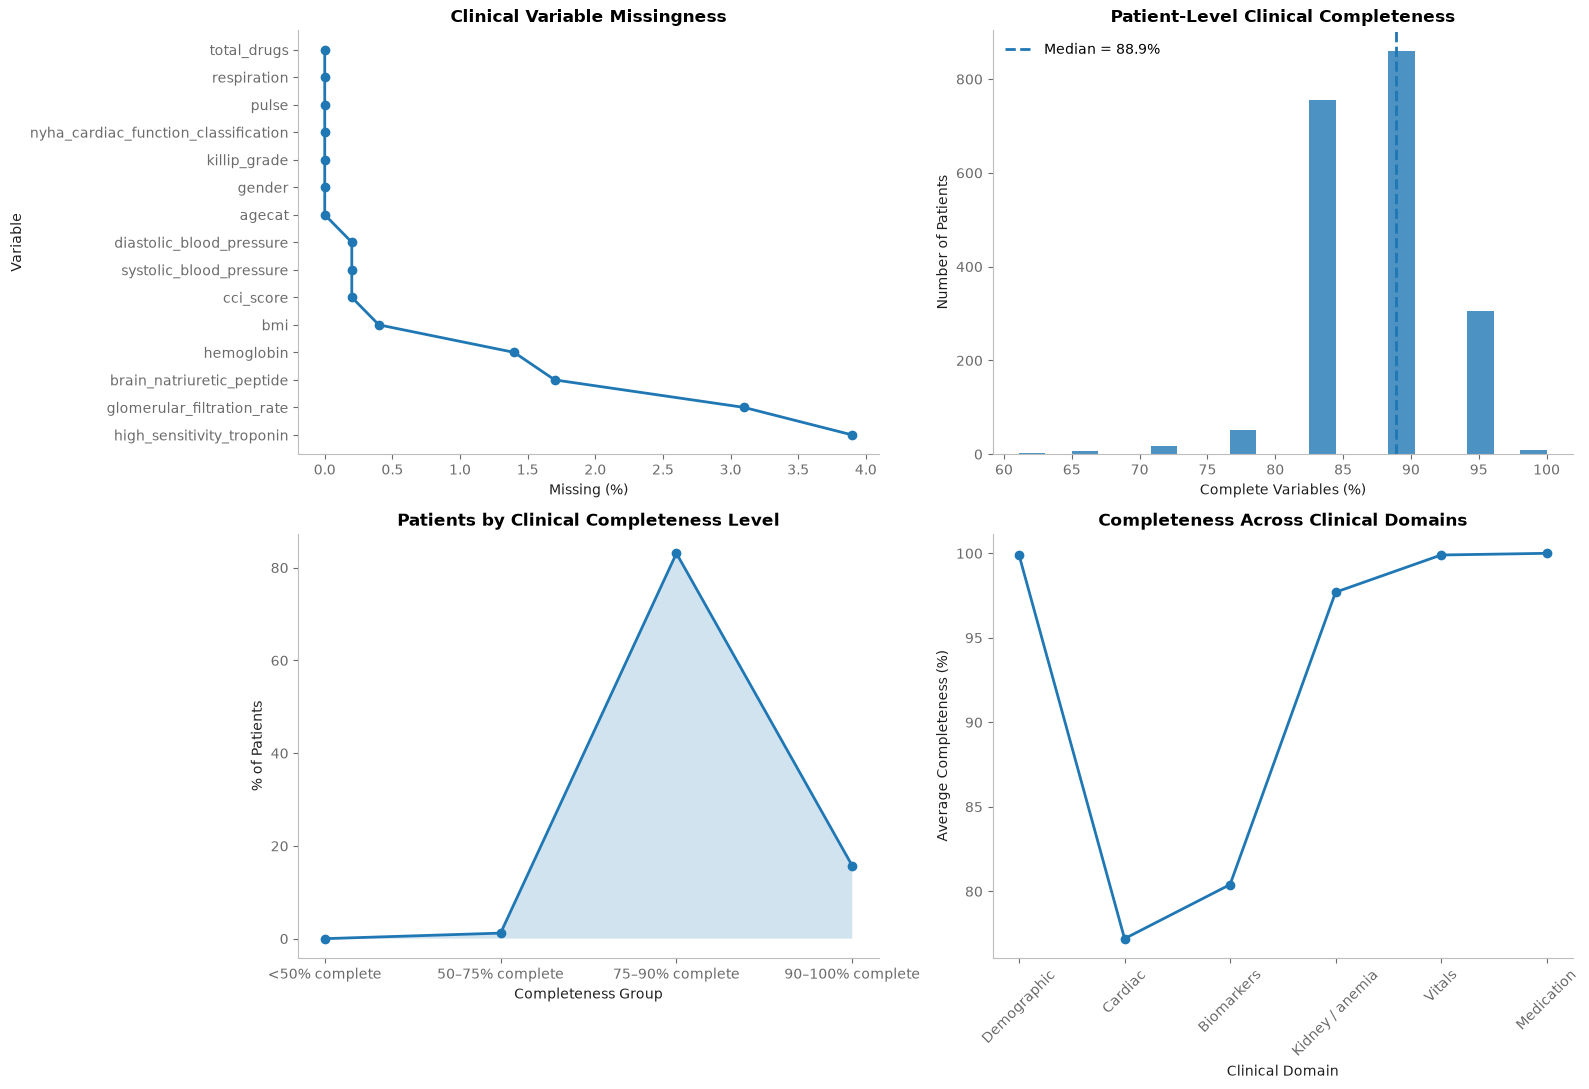

In [12]:
q10_cols = [
    "agecat", "gender","bmi","nyha_cardiac_function_classification",
    "killip_grade","lvef","brain_natriuretic_peptide","high_sensitivity_troponin","hs_crp","glomerular_filtration_rate",
    "hemoglobin","systolic_blood_pressure","diastolic_blood_pressure","pulse","respiration", "respiratory_support","cci_score","total_drugs"]

q10 = df[q10_cols].copy()


# ------------------------------------------------------------
# 1. Missingness by variable
# ------------------------------------------------------------

missing_by_column = (
    q10.isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)

print("Missing Information by Variable (%)")

display(
    missing_by_column
    .rename("missing_%")
    .to_frame()
)


# ------------------------------------------------------------
# 2. Completeness by variable
# ------------------------------------------------------------

completeness_by_column = (
    q10.notna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=True)
)

print("Completeness by Variable (%)")

display(
    completeness_by_column
    .rename("complete_%")
    .to_frame()
)


# ------------------------------------------------------------
# 3. Overall patient-level completeness
# ------------------------------------------------------------

patient_completeness = (
    q10.notna()
    .mean(axis=1)
    .mul(100)
)

print(
    "Average patient-level completeness:",
    round(patient_completeness.mean(), 1),
    "%"
)

print(
    "Median patient-level completeness:",
    round(patient_completeness.median(), 1),
    "%"
)


# ------------------------------------------------------------
# 4. Completeness groups
# ------------------------------------------------------------

completeness_group = pd.cut(patient_completeness,bins=[0, 50, 75, 90, 100],
                            include_lowest=True,
    labels=["<50% complete","50–75% complete","75–90% complete", "90–100% complete"])

group_distribution = (
    completeness_group
    .value_counts()
    .sort_index()
)

group_percentage = (
    group_distribution
    .div(len(q10))
    .mul(100)
    .round(1)
    .rename("percentage")
    .to_frame()
)

print("Patient-Level Completeness Groups (%)")
display(group_percentage)


# ============================================================
# Advanced Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))


# ------------------------------------------------------------
# A. Missingness profile
# ------------------------------------------------------------

top_missing = missing_by_column.tail(15)

axes[0, 0].plot(
    top_missing.values,
    top_missing.index,
    marker="o",
    linewidth=2
)

axes[0, 0].set_title( "Clinical Variable Missingness")
axes[0, 0].set_xlabel( "Missing (%)")
axes[0, 0].set_ylabel(  "Variable")


# ------------------------------------------------------------
# B. Completeness profile
# ------------------------------------------------------------

axes[0, 1].hist( patient_completeness, bins=20,alpha=0.8)
axes[0, 1].axvline( patient_completeness.median(),  linestyle="--", linewidth=2, label=(  f"Median = " f"{patient_completeness.median():.1f}%" ))
axes[0, 1].set_title( "Patient-Level Clinical Completeness")
axes[0, 1].set_xlabel(  "Complete Variables (%)")
axes[0, 1].set_ylabel(  "Number of Patients")
axes[0, 1].legend()


# ------------------------------------------------------------
# C. Completeness group profile
# ------------------------------------------------------------

axes[1, 0].plot(  group_percentage.index.astype(str), group_percentage["percentage"].values, marker="o", linewidth=2)
axes[1, 0].fill_between(   range(len(group_percentage)),  group_percentage["percentage"].values,  alpha=0.2)
axes[1, 0].set_title  ( "Patients by Clinical Completeness Level")
axes[1, 0].set_xlabel(  "Completeness Group")
axes[1, 0].set_ylabel(  "% of Patients")


# ------------------------------------------------------------
# D. Domain completeness
# ------------------------------------------------------------

domain_groups = {
    "Demographic": ["agecat","gender", "bmi" ],
    "Cardiac": [   "nyha_cardiac_function_classification","killip_grade", "lvef" ],
    "Biomarkers": ["brain_natriuretic_peptide", "high_sensitivity_troponin", "hs_crp" ],
    "Kidney / anemia": [ "glomerular_filtration_rate",  "hemoglobin" ],
    "Vitals": [ "systolic_blood_pressure","diastolic_blood_pressure",  "pulse",  "respiration" ],
    "Medication": [   "total_drugs"]}

domain_completeness = {}

for domain, cols in domain_groups.items():
    domain_completeness[domain] = (
        q10[cols]
        .notna()
        .mean()
        .mean()
        * 100
    )

domain_completeness = pd.Series(
    domain_completeness
).round(1)

axes[1, 1].plot(
    domain_completeness.index,
    domain_completeness.values,
    marker="o",
    linewidth=2
)

axes[1, 1].set_title( "Completeness Across Clinical Domains")
axes[1, 1].set_xlabel( "Clinical Domain")
axes[1, 1].set_ylabel("Average Completeness (%)")
axes[1, 1].tick_params(  axis="x",  rotation=45)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Diuretics (96%) and spironolactone (91%) are given to nearly everyone, and digitalis (66%) and IV inotropes (36%) are also used a lot. But only about 38% get an ACE inhibitor/ARB or a beta-blocker, and <b>only 19% get the full recommended combination</b>. The median patient takes 8 drugs, and 90% take 5 or more (polypharmacy).</b></i></p>